In [ ]:
!pip install zoobot[pytorch_colab]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.4/848.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.3/75.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/mydrive',force_remount=True)

Mounted at /content/mydrive


In [ ]:
import os
print(os.listdir('/content/mydrive/MyDrive/'))

['Colab Notebooks', 'IMG-20250322-WA0002.jpg', 'IMG-20250311-WA0015.jpg', 'IMG-20250322-WA0003.jpg', 'IMG-20250319-WA0034.jpg', 'Adobe Scan 02 Feb 2022.pdf', 'Physics Zaman Academy ', 'IISERB_12092024_351874932.PDF', 'Screenshot_20240917-192249_WhatsApp.jpg', '20241019_190533.mp4', 'cs endsem prep.gdoc', '20250117_163936.mp4', 'ISHITA PANDA (24F80118).pdf', 'MyCV.docx', 'MyCV2.docx', 'InAmigos', 'Untitled spreadsheet.gsheet', '24CS8194_Assignment1.gdoc', '15th Aug 25 script.pdf', '15th Aug 25 script.gdoc', "Orientation'25 (RN)", 'improvise this.gsheet', 'i told u not to include command lines...dikhta nh....gsheet', 'Screenshot_20251105_205249_WhatsApp.jpg', 'IMG-20251105-WA0008.jpg', 'winter_training_noc_format.gdoc', 'Fictionary Theme Ideas.gdoc', 'fictionary day 2.gdoc', 'Sahanur.gsheet', 'Untitled document.gdoc', 'ASS 5 DBMS (1).pdf', 'ASS 5 DBMS.pdf', 'ASSIGNMENT 6.pdf', 'galaxy_zoo', 'Galaxy_enhanced']


In [ ]:
import zipfile
import os

# Create destination folders
os.makedirs('/content/mydrive/MyDrive/galaxy_zoo/images_test_rev1/', exist_ok=True)
os.makedirs('/content/mydrive/MyDrive/galaxy_zoo/images_training_rev1/', exist_ok=True)

# Unzip training set
print("Unzipping training set...")
with zipfile.ZipFile('/content/mydrive/MyDrive/galaxy_zoo/images_training_rev1.zip', 'r') as z:
    z.extractall('/content/mydrive/MyDrive/galaxy_zoo/images_training_rev1/')
print("Done! Training set ready.")

# Unzip test set
print("Unzipping test set...")
with zipfile.ZipFile('/content/mydrive/MyDrive/galaxy_zoo/images_test_rev1.zip', 'r') as z:
    z.extractall('/content/mydrive/MyDrive/galaxy_zoo/images_test_rev1/')
print("Done! Test set ready.")

Unzipping training set...


In [ ]:
training_count = len(os.listdir('/content/mydrive/MyDrive/galaxy_zoo/images_training_rev1/images_training_rev1/'))
test_count = len(os.listdir('/content/mydrive/MyDrive/galaxy_zoo/images_test_rev1/images_test_rev1/'))

print(f"Training images: {training_count}")
print(f"Test images: {test_count}")

In [ ]:
import pandas as pd
import numpy as np
import torch
from zoobot.pytorch.training import finetune
from zoobot.pytorch.predictions import predict_on_catalog

# Load ground truth labels
solutions = pd.read_csv('/content/mydrive/MyDrive/galaxy_zoo/training_solutions_rev1.csv')
print(solutions.shape)      # should be (61578, 38) — GalaxyID + 37 vote fractions
print(solutions.head())

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping
(61578, 38)
   GalaxyID  Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class3.1  \
0    100008  0.383147  0.616853  0.000000  0.000000  0.616853  0.038452   
1    100023  0.327001  0.663777  0.009222  0.031178  0.632599  0.467370   
2    100053  0.765717  0.177352  0.056931  0.000000  0.177352  0.000000   
3    100078  0.693377  0.238564  0.068059  0.000000  0.238564  0.109493   
4    100090  0.933839  0.000000  0.066161  0.000000  0.000000  0.000000   

   Class3.2  Class4.1  Class4.2  ...  Class9.3  Class10.1  Class10.2  \
0  0.578401  0.418398  0.198455  ...  0.000000   0.279952   0.138445   
1  0.165229  0.591328  0.041271  ...  0.018764   0.000000   0.131378   
2  0.177352  0.000000  0.177352  ...  0.000000   0.000000   0.000000   
3  0.129071  0.189098  0.049466  ...  0.000000   0.094549   0.000000   
4  0.000000  0.000000  0.000000  ...  0.000000   0.000000   0.000000   

   Class10.3  Class11

In [ ]:
import os
import glob
import pandas as pd

# Get all training image paths
image_paths = glob.glob('/content/mydrive/MyDrive/galaxy_zoo/images_training_rev1/images_training_rev1/*.jpg')

# Extract galaxy IDs from filenames (filename is GalaxyID.jpg)
image_df = pd.DataFrame({
    'file_loc': image_paths,
    'GalaxyID': [int(os.path.basename(p).replace('.jpg', '')) for p in image_paths]
})

# Merge with solutions to get ground truth
merged = image_df.merge(solutions, on='GalaxyID')
print(f"Matched {len(merged)} images with ground truth labels")

Matched 61578 images with ground truth labels


In [ ]:
sample = merged.sample(n=500, random_state=42).reset_index(drop=True)

# Save just the file paths for Zoobot
predict_df = sample[['file_loc']].copy()

In [ ]:
from zoobot.pytorch.training import finetune
from zoobot.shared import schemas

model = finetune.FinetuneableZoobotTree(
    name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    schema=schemas.gz2_ortho_schema
)
model.eval()

# Check what label cols it uses
print(schemas.gz2_ortho_schema.label_cols)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/59.9M [00:00<?, ?B/s]

['smooth-or-featured-gz2_smooth', 'smooth-or-featured-gz2_featured-or-disk', 'smooth-or-featured-gz2_artifact', 'disk-edge-on-gz2_yes', 'disk-edge-on-gz2_no', 'has-spiral-arms-gz2_yes', 'has-spiral-arms-gz2_no', 'bar-gz2_yes', 'bar-gz2_no', 'bulge-size-gz2_dominant', 'bulge-size-gz2_obvious', 'bulge-size-gz2_just-noticeable', 'bulge-size-gz2_no', 'something-odd-gz2_yes', 'something-odd-gz2_no', 'how-rounded-gz2_round', 'how-rounded-gz2_in-between', 'how-rounded-gz2_cigar', 'bulge-shape-gz2_round', 'bulge-shape-gz2_boxy', 'bulge-shape-gz2_no-bulge', 'spiral-winding-gz2_tight', 'spiral-winding-gz2_medium', 'spiral-winding-gz2_loose', 'spiral-arm-count-gz2_1', 'spiral-arm-count-gz2_2', 'spiral-arm-count-gz2_3', 'spiral-arm-count-gz2_4', 'spiral-arm-count-gz2_more-than-4', 'spiral-arm-count-gz2_cant-tell']


In [ ]:
# Exact mapping: Zoobot gz2_ortho_schema → Kaggle column names
zoobot_to_kaggle = {
    'smooth-or-featured-gz2_smooth':             'Class1.1',
    'smooth-or-featured-gz2_featured-or-disk':   'Class1.2',
    'smooth-or-featured-gz2_artifact':            'Class1.3',
    'disk-edge-on-gz2_yes':                       'Class2.1',
    'disk-edge-on-gz2_no':                        'Class2.2',
    'has-spiral-arms-gz2_yes':                    'Class4.1',
    'has-spiral-arms-gz2_no':                     'Class4.2',
    'bar-gz2_yes':                                'Class5.1',
    'bar-gz2_no':                                 'Class5.2',
    'bulge-size-gz2_dominant':                    'Class6.1',
    'bulge-size-gz2_obvious':                     'Class6.2',
    'bulge-size-gz2_just-noticeable':             'Class6.3',
    'bulge-size-gz2_no':                          'Class6.4',
    'something-odd-gz2_yes':                      'Class8.1',
    'something-odd-gz2_no':                       'Class8.2',
    'how-rounded-gz2_round':                      'Class7.1',
    'how-rounded-gz2_in-between':                 'Class7.2',
    'how-rounded-gz2_cigar':                      'Class7.3',
    'bulge-shape-gz2_round':                      'Class9.1',
    'bulge-shape-gz2_boxy':                       'Class9.2',
    'bulge-shape-gz2_no-bulge':                   'Class9.3',
    'spiral-winding-gz2_tight':                   'Class10.1',
    'spiral-winding-gz2_medium':                  'Class10.2',
    'spiral-winding-gz2_loose':                   'Class10.3',
    'spiral-arm-count-gz2_1':                     'Class11.1',
    'spiral-arm-count-gz2_2':                     'Class11.2',
    'spiral-arm-count-gz2_3':                     'Class11.3',
    'spiral-arm-count-gz2_4':                     'Class11.4',
    'spiral-arm-count-gz2_more-than-4':           'Class11.5',
    'spiral-arm-count-gz2_cant-tell':             'Class11.6',
}

# The 7 Kaggle columns Zoobot doesn't cover
missing_kaggle_cols = ['Class3.1', 'Class3.2', 'Class5.3', 'Class5.4', 'Class8.3',
                       'Class8.4', 'Class8.5', 'Class8.6', 'Class8.7']

print(f"Zoobot covers: {len(zoobot_to_kaggle)} columns")
print(f"Missing from Zoobot: {missing_kaggle_cols}")

Zoobot covers: 30 columns
Missing from Zoobot: ['Class3.1', 'Class3.2', 'Class5.3', 'Class5.4', 'Class8.3', 'Class8.4', 'Class8.5', 'Class8.6', 'Class8.7']


In [ ]:
# Add the required id_str column
predict_df = sample[['file_loc']].copy()
predict_df['id_str'] = predict_df['file_loc'].apply(lambda x: os.path.basename(x).replace('.jpg', ''))

print(f"Images ready: {len(predict_df)}")
print(predict_df.head())

Images ready: 500
                                            file_loc  id_str
0  /content/mydrive/MyDrive/galaxy_zoo/images_tra...  561811
1  /content/mydrive/MyDrive/galaxy_zoo/images_tra...  662284
2  /content/mydrive/MyDrive/galaxy_zoo/images_tra...  218238
3  /content/mydrive/MyDrive/galaxy_zoo/images_tra...  754376
4  /content/mydrive/MyDrive/galaxy_zoo/images_tra...  117206


In [ ]:
zoobot_to_kaggle = {
    # Question 1 — Smooth or Featured?
    'smooth-or-featured-gz2_smooth':            'Class1.1',
    'smooth-or-featured-gz2_featured-or-disk':  'Class1.2',
    'smooth-or-featured-gz2_artifact':          'Class1.3',

    # Question 2 — Edge on disk?
    'disk-edge-on-gz2_yes':                     'Class2.1',
    'disk-edge-on-gz2_no':                      'Class2.2',

    # Question 4 — Spiral arms?
    'has-spiral-arms-gz2_yes':                  'Class4.1',
    'has-spiral-arms-gz2_no':                   'Class4.2',

    # Question 5 — Bar?
    'bar-gz2_yes':                              'Class5.1',
    'bar-gz2_no':                               'Class5.2',

    # Question 6 — Bulge size?
    'bulge-size-gz2_dominant':                  'Class6.1',
    'bulge-size-gz2_obvious':                   'Class6.2',

    # Question 7 — How rounded?
    'how-rounded-gz2_round':                    'Class7.1',
    'how-rounded-gz2_in-between':               'Class7.2',
    'how-rounded-gz2_cigar':                    'Class7.3',

    # Question 8 — Something odd?
    'something-odd-gz2_yes':                    'Class8.1',
    'something-odd-gz2_no':                     'Class8.2',

    # Question 9 — Bulge shape?
    'bulge-shape-gz2_round':                    'Class9.1',
    'bulge-shape-gz2_boxy':                     'Class9.2',
    'bulge-shape-gz2_no-bulge':                 'Class9.3',

    # Question 10 — Spiral winding?
    'spiral-winding-gz2_tight':                 'Class10.1',
    'spiral-winding-gz2_medium':                'Class10.2',
    'spiral-winding-gz2_loose':                 'Class10.3',

    # Question 11 — Spiral arm count?
    'spiral-arm-count-gz2_1':                   'Class11.1',
    'spiral-arm-count-gz2_2':                   'Class11.2',
    'spiral-arm-count-gz2_3':                   'Class11.3',
    'spiral-arm-count-gz2_4':                   'Class11.4',
    'spiral-arm-count-gz2_more-than-4':         'Class11.5',
    'spiral-arm-count-gz2_cant-tell':           'Class11.6',
}

# Kaggle columns NOT covered by Zoobot
not_covered = ['Class3.1', 'Class3.2',           # edge-on bulge shape
               'Class5.3', 'Class5.4',           # bar detail
               'Class6.3', 'Class6.4',           # bulge size detail
               'Class8.3', 'Class8.4',
               'Class8.5', 'Class8.6', 'Class8.7']  # odd feature types

matched_kaggle_cols = list(zoobot_to_kaggle.values())
print(f"Matched columns: {len(matched_kaggle_cols)}")
print(f"Not covered by Zoobot: {not_covered}")

Matched columns: 28
Not covered by Zoobot: ['Class3.1', 'Class3.2', 'Class5.3', 'Class5.4', 'Class6.3', 'Class6.4', 'Class8.3', 'Class8.4', 'Class8.5', 'Class8.6', 'Class8.7']


In [ ]:
print(solutions.columns.tolist())

['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2', 'Class3.1', 'Class3.2', 'Class4.1', 'Class4.2', 'Class5.1', 'Class5.2', 'Class5.3', 'Class5.4', 'Class6.1', 'Class6.2', 'Class7.1', 'Class7.2', 'Class7.3', 'Class8.1', 'Class8.2', 'Class8.3', 'Class8.4', 'Class8.5', 'Class8.6', 'Class8.7', 'Class9.1', 'Class9.2', 'Class9.3', 'Class10.1', 'Class10.2', 'Class10.3', 'Class11.1', 'Class11.2', 'Class11.3', 'Class11.4', 'Class11.5', 'Class11.6']


In [ ]:
# Check exact Zoobot output columns
predictions_v2 = pd.read_csv('/content/zoobot_predictions_v2.csv')
print(predictions_v2.columns.tolist())


['smooth-or-featured-gz2_smooth', 'smooth-or-featured-gz2_featured-or-disk', 'smooth-or-featured-gz2_artifact', 'disk-edge-on-gz2_yes', 'disk-edge-on-gz2_no', 'has-spiral-arms-gz2_yes', 'has-spiral-arms-gz2_no', 'bar-gz2_yes', 'bar-gz2_no', 'bulge-size-gz2_dominant', 'bulge-size-gz2_obvious', 'bulge-size-gz2_just-noticeable', 'bulge-size-gz2_no', 'something-odd-gz2_yes', 'something-odd-gz2_no', 'how-rounded-gz2_round', 'how-rounded-gz2_in-between', 'how-rounded-gz2_cigar', 'bulge-shape-gz2_round', 'bulge-shape-gz2_boxy', 'bulge-shape-gz2_no-bulge', 'spiral-winding-gz2_tight', 'spiral-winding-gz2_medium', 'spiral-winding-gz2_loose', 'spiral-arm-count-gz2_1', 'spiral-arm-count-gz2_2', 'spiral-arm-count-gz2_3', 'spiral-arm-count-gz2_4', 'spiral-arm-count-gz2_more-than-4', 'spiral-arm-count-gz2_cant-tell', 'id_str']


In [ ]:
from PIL import Image
import numpy as np

# Compute mean and std from a sample of your images
sample_paths = sample['file_loc'].tolist()[:200]

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
pixel_count = 0

for path in sample_paths:
    img = np.array(Image.open(path).convert('RGB').crop(
        (108, 108, 315, 315)  # center crop 207x207 from 424x424
    )) / 255.0

    pixel_sum += img.mean(axis=(0,1))
    pixel_sq_sum += (img**2).mean(axis=(0,1))
    pixel_count += 1

mean = pixel_sum / pixel_count
std = np.sqrt(pixel_sq_sum / pixel_count - mean**2)

print(f"Computed mean: {mean.round(4).tolist()}")
print(f"Computed std:  {std.round(4).tolist()}")

Computed mean: [0.1076, 0.0932, 0.0737]
Computed std:  [0.1504, 0.1265, 0.1085]


In [ ]:
import torchvision.transforms.v2 as transforms_v2
from PIL import Image
from zoobot.pytorch.predictions import predict_on_catalog
from zoobot.pytorch.training import finetune
import torch
from zoobot.shared import schemas

inference_transform = transforms_v2.Compose([
    transforms_v2.CenterCrop(207),       # remove black border first
    transforms_v2.Resize((224, 224)),    # then resize to model input
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Normalize(
        mean=[0.1076, 0.0932, 0.0737],
        std=[0.1504, 0.1265, 0.1085]
    )
])

# See exactly what output columns GZ2 schema produces
print(schemas.gz2_ortho_schema.label_cols)



['smooth-or-featured-gz2_smooth', 'smooth-or-featured-gz2_featured-or-disk', 'smooth-or-featured-gz2_artifact', 'disk-edge-on-gz2_yes', 'disk-edge-on-gz2_no', 'has-spiral-arms-gz2_yes', 'has-spiral-arms-gz2_no', 'bar-gz2_yes', 'bar-gz2_no', 'bulge-size-gz2_dominant', 'bulge-size-gz2_obvious', 'bulge-size-gz2_just-noticeable', 'bulge-size-gz2_no', 'something-odd-gz2_yes', 'something-odd-gz2_no', 'how-rounded-gz2_round', 'how-rounded-gz2_in-between', 'how-rounded-gz2_cigar', 'bulge-shape-gz2_round', 'bulge-shape-gz2_boxy', 'bulge-shape-gz2_no-bulge', 'spiral-winding-gz2_tight', 'spiral-winding-gz2_medium', 'spiral-winding-gz2_loose', 'spiral-arm-count-gz2_1', 'spiral-arm-count-gz2_2', 'spiral-arm-count-gz2_3', 'spiral-arm-count-gz2_4', 'spiral-arm-count-gz2_more-than-4', 'spiral-arm-count-gz2_cant-tell']


In [ ]:
predict_on_catalog.predict(
    predict_df,
    model,
    label_cols=schemas.gz2_ortho_schema.label_cols,
    save_loc='/content/zoobot_predictions_v2.csv',
    inference_transform=inference_transform
)
predictions = pd.read_csv('/content/zoobot_predictions_v2.csv')
print(predictions.head())

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Output()

   smooth-or-featured-gz2_smooth  smooth-or-featured-gz2_featured-or-disk  \
0                      46.373910                                47.901474   
1                      46.208570                                45.131460   
2                      45.100636                                48.464092   
3                      44.294514                                50.067966   
4                      41.167500                                45.910480   

   smooth-or-featured-gz2_artifact  disk-edge-on-gz2_yes  disk-edge-on-gz2_no  \
0                        43.766857             30.741425            53.585667   
1                        44.540770             39.327210            57.311386   
2                        38.084260             34.475220            62.440180   
3                        46.888990             33.824432            63.802494   
4                        45.187810             38.713420            57.466972   

   has-spiral-arms-gz2_yes  has-spiral-arms-gz2_no

In [ ]:
# Check Zoobot output columns
predictions = pd.read_csv('/content/zoobot_predictions_v2.csv')
print("Zoobot output columns:")
print(predictions.columns.tolist())

# Check Kaggle solution columns
print("\nKaggle solution columns:")
print(solutions.columns.tolist())

Zoobot output columns:
['smooth-or-featured-gz2_smooth', 'smooth-or-featured-gz2_featured-or-disk', 'smooth-or-featured-gz2_artifact', 'disk-edge-on-gz2_yes', 'disk-edge-on-gz2_no', 'has-spiral-arms-gz2_yes', 'has-spiral-arms-gz2_no', 'bar-gz2_yes', 'bar-gz2_no', 'bulge-size-gz2_dominant', 'bulge-size-gz2_obvious', 'bulge-size-gz2_just-noticeable', 'bulge-size-gz2_no', 'something-odd-gz2_yes', 'something-odd-gz2_no', 'how-rounded-gz2_round', 'how-rounded-gz2_in-between', 'how-rounded-gz2_cigar', 'bulge-shape-gz2_round', 'bulge-shape-gz2_boxy', 'bulge-shape-gz2_no-bulge', 'spiral-winding-gz2_tight', 'spiral-winding-gz2_medium', 'spiral-winding-gz2_loose', 'spiral-arm-count-gz2_1', 'spiral-arm-count-gz2_2', 'spiral-arm-count-gz2_3', 'spiral-arm-count-gz2_4', 'spiral-arm-count-gz2_more-than-4', 'spiral-arm-count-gz2_cant-tell', 'id_str']

Kaggle solution columns:
['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2', 'Class3.1', 'Class3.2', 'Class4.1', 'Class4.2', 'Class

In [ ]:
import inspect
print(inspect.signature(predict_on_catalog.predict))

(catalog: pandas.core.frame.DataFrame, model: lightning.pytorch.core.module.LightningModule, save_loc: str, label_cols: List[str], inference_transform: torchvision.transforms.v2._container.Compose, datamodule_kwargs={}, trainer_kwargs={}) -> pandas.core.frame.DataFrame


In [ ]:
# Step 1 — Load raw predictions from CSV
predictions_v2 = pd.read_csv('/content/zoobot_predictions_v2.csv')

# Step 2 — Rename Zoobot column names to Kaggle column names
predictions_renamed = predictions_v2.rename(columns=zoobot_to_kaggle)

print(predictions_renamed.columns.tolist())
print(predictions_renamed.shape)

['Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2', 'Class4.1', 'Class4.2', 'Class5.1', 'Class5.2', 'Class6.1', 'Class6.2', 'Class6.3', 'Class6.4', 'Class8.1', 'Class8.2', 'Class7.1', 'Class7.2', 'Class7.3', 'Class9.1', 'Class9.2', 'Class9.3', 'Class10.1', 'Class10.2', 'Class10.3', 'Class11.1', 'Class11.2', 'Class11.3', 'Class11.4', 'Class11.5', 'Class11.6', 'id_str']
(500, 31)


In [ ]:
# Zoobot outputs raw vote counts per question group
# We need to normalize within each question so they sum to 1

# Define question groups — columns belonging to same question must sum to 1
question_groups = [
    ['Class1.1', 'Class1.2', 'Class1.3'],
    ['Class2.1', 'Class2.2'],
    ['Class4.1', 'Class4.2'],
    ['Class5.1', 'Class5.2'],
    ['Class6.1', 'Class6.2'],
    ['Class7.1', 'Class7.2', 'Class7.3'],
    ['Class8.1', 'Class8.2'],
    ['Class9.1', 'Class9.2', 'Class9.3'],
    ['Class10.1', 'Class10.2', 'Class10.3'],
    ['Class11.1', 'Class11.2', 'Class11.3', 'Class11.4', 'Class11.5', 'Class11.6'],
]

# Normalize each question group so votes sum to 1
predictions_normalized = predictions_renamed.copy()
for group in question_groups:
    # Only normalize columns that exist in our matched set
    group_cols = [c for c in group if c in matched_kaggle_cols]
    if group_cols:
        row_sums = predictions_normalized[group_cols].sum(axis=1)
        predictions_normalized[group_cols] = predictions_normalized[group_cols].div(row_sums, axis=0)

# Verify normalization worked — each group should now sum to ~1
print("Sample normalized predictions (first 3 rows):")
print(predictions_normalized[matched_kaggle_cols].head(3).round(4))

print("\nNormalized value ranges (should be 0-1):")
print(predictions_normalized[matched_kaggle_cols].describe().round(4))

Sample normalized predictions (first 3 rows):
   Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class4.1  Class4.2  \
0    0.3359    0.3470    0.3171    0.3645    0.6355    0.6500    0.3500   
1    0.3401    0.3321    0.3278    0.4070    0.5930    0.4497    0.5503   
2    0.3426    0.3681    0.2893    0.3557    0.6443    0.4645    0.5355   

   Class5.1  Class5.2  Class6.1  ...  Class9.3  Class10.1  Class10.2  \
0    0.5017    0.4983    0.5820  ...    0.3154     0.3665     0.2776   
1    0.4533    0.5467    0.5718  ...    0.2986     0.3927     0.3017   
2    0.4663    0.5337    0.5476  ...    0.2903     0.3845     0.2773   

   Class10.3  Class11.1  Class11.2  Class11.3  Class11.4  Class11.5  Class11.6  
0     0.3559     0.1598     0.0942     0.2265     0.2059     0.1534     0.1602  
1     0.3056     0.1678     0.1057     0.2141     0.2207     0.1655     0.1262  
2     0.3382     0.1718     0.0970     0.2198     0.2357     0.1481     0.1274  

[3 rows x 28 columns]

Normalized value

In [ ]:
ground_truth = sample[matched_kaggle_cols].reset_index(drop=True).values
predicted = predictions_normalized[matched_kaggle_cols].values

rmse = np.sqrt(np.mean((predicted - ground_truth) ** 2))
print(f"\nZoobot RMSE (normalized, 28 matched columns): {rmse:.5f}")
print(f"Dieleman winner (all 37):                     0.07492")
print(f"Central pixel baseline:                       0.16194")
print(f"Decent range:                                 0.10 - 0.12")


Zoobot RMSE (normalized, 28 matched columns): 0.32773
Dieleman winner (all 37):                     0.07492
Central pixel baseline:                       0.16194
Decent range:                                 0.10 - 0.12


In [ ]:
print("Sample predictions (first 3 rows):")
print(predictions_renamed[matched_kaggle_cols].head(3))

print("\nPrediction value ranges:")
print(predictions_renamed[matched_kaggle_cols].describe())

print("\nGround truth value ranges:")
print(sample[matched_kaggle_cols].describe())

Sample predictions (first 3 rows):
    Class1.1   Class1.2   Class1.3   Class2.1   Class2.2   Class4.1  \
0  46.373910  47.901474  43.766857  30.741425  53.585667  58.061417   
1  46.208570  45.131460  44.540770  39.327210  57.311386  40.252310   
2  45.100636  48.464092  38.084260  34.475220  62.440180  37.615000   

    Class4.2   Class5.1   Class5.2   Class6.1  ...   Class9.3  Class10.1  \
0  31.264223  60.848700  60.431694  67.164950  ...  49.641026  56.336044   
1  49.258550  56.349422  67.958330  72.298965  ...  37.939106  54.097855   
2  43.370155  61.932710  70.891655  69.871550  ...  35.484150  52.452500   

   Class10.2  Class10.3  Class11.1  Class11.2  Class11.3  Class11.4  \
0  42.666450  54.708755  48.894344  28.831210  69.321800  63.021626   
1  41.565174  42.104040  57.040870  35.941830  72.790510  75.043480   
2  37.837337  46.140010  58.230240  32.883858  74.489006  79.883660   

   Class11.5  Class11.6  
0  46.948200  49.025383  
1  56.288876  42.915997  
2  50.183945

Original image size: (424, 424)
Original image mode: RGB
After crop: (207, 207)
After resize: (224, 224)


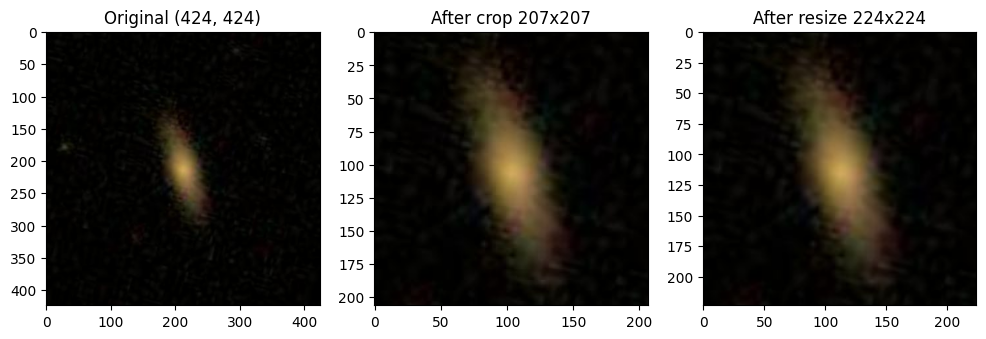

In [ ]:
# Check 1: Verify what your images actually look like after transform
from PIL import Image
import torchvision.transforms.v2 as transforms_v2
import torch
import matplotlib.pyplot as plt

# Load one image and apply transform
img = Image.open(sample['file_loc'].iloc[0])
print(f"Original image size: {img.size}")
print(f"Original image mode: {img.mode}")

# Apply transform step by step
crop = transforms_v2.CenterCrop(207)
img_cropped = crop(img)
print(f"After crop: {img_cropped.size}")

resize = transforms_v2.Resize((224, 224))
img_resized = resize(img_cropped)
print(f"After resize: {img_resized.size}")

# Show both
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title(f'Original {img.size}')
axes[1].imshow(img_cropped)
axes[1].set_title(f'After crop 207x207')
axes[2].imshow(img_resized)
axes[2].set_title(f'After resize 224x224')
plt.show()

In [ ]:
# Check 2: Verify predictions are actually varying meaningfully
# If the model is confused, all predictions will be near uniform (0.33 for 3-way, 0.5 for 2-way)
print("Mean predictions per column:")
print(predictions_normalized[matched_kaggle_cols].mean().round(4))

print("\nMean ground truth per column:")
print(sample[matched_kaggle_cols].mean().round(4))

Mean predictions per column:
Class1.1     0.3376
Class1.2     0.3348
Class1.3     0.3276
Class2.1     0.3973
Class2.2     0.6027
Class4.1     0.5328
Class4.2     0.4672
Class5.1     0.4928
Class5.2     0.5072
Class6.1     0.5533
Class6.2     0.4467
Class7.1     0.4152
Class7.2     0.2437
Class7.3     0.3411
Class8.1     0.4553
Class8.2     0.5447
Class9.1     0.3318
Class9.2     0.3419
Class9.3     0.3263
Class10.1    0.3724
Class10.2    0.2791
Class10.3    0.3485
Class11.1    0.1633
Class11.2    0.1013
Class11.3    0.2184
Class11.4    0.2222
Class11.5    0.1575
Class11.6    0.1373
dtype: float64

Mean ground truth per column:
Class1.1     0.4261
Class1.2     0.5481
Class1.3     0.0258
Class2.1     0.1031
Class2.2     0.4449
Class4.1     0.2258
Class4.2     0.2192
Class5.1     0.0403
Class5.2     0.1969
Class6.1     0.2251
Class6.2     0.7749
Class7.1     0.1613
Class7.2     0.2062
Class7.3     0.0587
Class8.1     0.0330
Class8.2     0.0110
Class9.1     0.0647
Class9.2     0.0114
Class

In [ ]:
print(inference_transform)

Compose(
      CenterCrop(size=(207, 207))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.1076, 0.0932, 0.0737], std=[0.1504, 0.1265, 0.1085], inplace=False)
)


In [ ]:
print([x for x in dir(finetune) if 'zoo' in x.lower() or 'encoder' in x.lower()])

['FinetuneableZoobotAbstract', 'FinetuneableZoobotClassifier', 'FinetuneableZoobotRegressor', 'FinetuneableZoobotTree', 'load_pretrained_zoobot']


In [ ]:
from zoobot.pytorch.training import finetune
from zoobot.shared import schemas
import torch.nn as nn

# Load the full FinetuneableZoobotTree model with a schema
model = finetune.FinetuneableZoobotTree(
    name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    schema=schemas.gz2_ortho_schema # Provide a valid schema
)
encoder = model.encoder # Extract the encoder backbone
encoder.eval() # Set the encoder to evaluation mode

print("Encoder loaded and set to eval mode!")

Encoder loaded and set to eval mode!


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms_v2
from PIL import Image
from zoobot.pytorch.predictions import predict_on_catalog
from zoobot.pytorch.training import finetune
import torch
from zoobot.shared import schemas
# Step 2 — Define a simple dataset to load images
class GalaxyDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df['file_loc'][idx]).convert('RGB')
        return self.transform(img)

dataset = GalaxyDataset(sample, inference_transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)
print(f"Dataset ready: {len(dataset)} images")

Dataset ready: 500 images


In [ ]:
# Step 3 — Extract features from all images
features_list = []
with torch.no_grad():
    for batch in loader:
        feats = encoder(batch)
        features_list.append(feats.cpu().numpy())

features = np.concatenate(features_list, axis=0)
print(f"Features shape: {features.shape}")  # should be (500, 512) or similar

Features shape: (500, 640)


In [ ]:
# Step 4 — Train a simple regression head on Kaggle labels
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(
    features,
    sample[matched_kaggle_cols].values,
    test_size=0.2,
    random_state=42
)

# Train a Ridge regression — one per output column
from sklearn.multioutput import MultiOutputRegressor

regressor = MultiOutputRegressor(Ridge(alpha=1.0))
regressor.fit(X_train, y_train)
print("Regression head trained!")

Regression head trained!


In [ ]:
# Step 5 — Predict and calculate RMSE
y_pred = regressor.predict(X_val)

# Clip to 0-1 range
y_pred = np.clip(y_pred, 0, 1)

rmse = np.sqrt(np.mean((y_pred - y_val) ** 2))
print(f"\nZoobot + Ridge RMSE: {rmse:.5f}")
print(f"Dieleman winner:     0.07492")
print(f"Baseline:            0.16194")
print(f"Decent range:        0.10 - 0.12")


Zoobot + Ridge RMSE: 0.11527
Dieleman winner:     0.07492
Baseline:            0.16194
Decent range:        0.10 - 0.12


In [ ]:
import os
print(os.listdir('/content/mydrive/MyDrive/'))

['Colab Notebooks', 'IMG-20250322-WA0002.jpg', 'IMG-20250311-WA0015.jpg', 'IMG-20250322-WA0003.jpg', 'IMG-20250319-WA0034.jpg', 'Adobe Scan 02 Feb 2022.pdf', 'Physics Zaman Academy ', 'IISERB_12092024_351874932.PDF', 'Screenshot_20240917-192249_WhatsApp.jpg', '20241019_190533.mp4', 'cs endsem prep.gdoc', '20250117_163936.mp4', 'ISHITA PANDA (24F80118).pdf', 'MyCV.docx', 'MyCV2.docx', 'InAmigos', 'Untitled spreadsheet.gsheet', '24CS8194_Assignment1.gdoc', '15th Aug 25 script.pdf', '15th Aug 25 script.gdoc', "Orientation'25 (RN)", 'improvise this.gsheet', 'i told u not to include command lines...dikhta nh....gsheet', 'Screenshot_20251105_205249_WhatsApp.jpg', 'IMG-20251105-WA0008.jpg', 'winter_training_noc_format.gdoc', 'Fictionary Theme Ideas.gdoc', 'fictionary day 2.gdoc', 'Sahanur.gsheet', 'Untitled document.gdoc', 'ASS 5 DBMS (1).pdf', 'ASS 5 DBMS.pdf', 'ASSIGNMENT 6.pdf', 'galaxy_zoo', 'Galaxy_enhanced']


In [ ]:
import glob
import os
import pandas as pd
import re

enhanced_paths = glob.glob('/content/mydrive/MyDrive/Galaxy_enhanced/**/*.jpg', recursive=True)

def extract_id(path):
    filename = os.path.basename(path)
    match = re.search(r'(\d+)', filename)
    return int(match.group(1)) if match else None

enhanced_df = pd.DataFrame({
    'file_loc': enhanced_paths,
    'GalaxyID': [extract_id(p) for p in enhanced_paths]
})

# Drop any rows where ID extraction failed
enhanced_df = enhanced_df.dropna(subset=['GalaxyID'])
enhanced_df['GalaxyID'] = enhanced_df['GalaxyID'].astype(int)

print(f"Total enhanced images found: {len(enhanced_df)}")
print(enhanced_df.tail())

Total enhanced images found: 61596
                                                file_loc  GalaxyID
61591  /content/mydrive/MyDrive/Galaxy_enhanced/f2/87...    876639
61592  /content/mydrive/MyDrive/Galaxy_enhanced/f2/17...    176168
61593  /content/mydrive/MyDrive/Galaxy_enhanced/f2/91...    919317
61594  /content/mydrive/MyDrive/Galaxy_enhanced/f2/14...    149870
61595  /content/mydrive/MyDrive/Galaxy_enhanced/f2/62...    622735


In [ ]:
# Step 1 — Match enhanced images to the same GalaxyIDs used in original sample
enhanced_sample = enhanced_df[enhanced_df['GalaxyID'].isin(sample['GalaxyID'])].reset_index(drop=True)
print(f"Original sample size:        {len(sample)}")
print(f"Matched enhanced images:     {len(enhanced_sample)}")

# Check for any missing IDs
missing_ids = set(sample['GalaxyID']) - set(enhanced_sample['GalaxyID'])
print(f"GalaxyIDs in original but not in enhanced: {len(missing_ids)}")

Original sample size:        500
Matched enhanced images:     500
GalaxyIDs in original but not in enhanced: 0


In [ ]:
merged_2=enhanced_df.merge(solutions, on='GalaxyID')
print(f"Matched {len(merged_2)} images with ground truth labels")

sample_2=merged_2.sample(n=500, random_state=42).reset_index(drop=True)
predict_df_2=sample_2[['file_loc']].copy()
predict_df_2['id_str'] = predict_df_2['file_loc'].apply(lambda x: os.path.basename(x).replace('.jpg', ''))

print(f"Images ready: {len(predict_df_2)}")
print(sample_2.head())
print(predict_df_2.head())

Matched 61596 images with ground truth labels
Images ready: 500
                                            file_loc  GalaxyID  Class1.1  \
0  /content/mydrive/MyDrive/Galaxy_enhanced/f5/34...    345268  0.151824   
1  /content/mydrive/MyDrive/Galaxy_enhanced/f7/28...    284955  0.188774   
2  /content/mydrive/MyDrive/Galaxy_enhanced/f7/46...    462356  0.939916   
3  /content/mydrive/MyDrive/Galaxy_enhanced/f8/56...    563763  0.085611   
4  /content/mydrive/MyDrive/Galaxy_enhanced/f4/95...    951355  0.672040   

   Class1.2  Class1.3  Class2.1  Class2.2  Class3.1  Class3.2  Class4.1  ...  \
0  0.824031  0.024145  0.017237  0.806794  0.053517  0.753277  0.172511  ...   
1  0.811226  0.000000  0.811226  0.000000  0.000000  0.000000  0.000000  ...   
2  0.060084  0.000000  0.000000  0.060084  0.000000  0.060084  0.000000  ...   
3  0.914389  0.000000  0.000000  0.914389  0.793597  0.120792  0.814209  ...   
4  0.299463  0.028497  0.000000  0.299463  0.000000  0.299463  0.230075  ...   

In [ ]:
# Find duplicate GalaxyIDs
duplicates = enhanced_df[enhanced_df['GalaxyID'].duplicated(keep=False)]
print(f"Total duplicate rows: {len(duplicates)}")
#print(duplicates.sort_values('GalaxyID').head(20))

Total duplicate rows: 36


In [ ]:
enhanced_df = enhanced_df.drop_duplicates(subset='GalaxyID', keep='first').reset_index(drop=True)
print(f"After removing duplicates: {len(enhanced_df)} images")

After removing duplicates: 61578 images


In [ ]:
# Step 2 — Build predict_df for enhanced images
enhanced_predict_df = enhanced_sample[['file_loc']].copy()
enhanced_predict_df['id_str'] = enhanced_sample['GalaxyID'].astype(str)
print(enhanced_predict_df.head())

                                            file_loc  id_str
0  /content/mydrive/MyDrive/Galaxy_enhanced/f1/81...  816260
1  /content/mydrive/MyDrive/Galaxy_enhanced/f1/10...  107272
2  /content/mydrive/MyDrive/Galaxy_enhanced/f1/51...  516030
3  /content/mydrive/MyDrive/Galaxy_enhanced/f1/29...  296206
4  /content/mydrive/MyDrive/Galaxy_enhanced/f1/26...  267106


In [ ]:
enh_img = Image.open(enh_path).convert('RGB')
print(f"Enhanced image size: {enh_img.size}")
print(f"Original image size: {orig_img.size}")

enh_w, enh_h = enh_img.size

# Crop proportionally — same 49% center crop ratio as original
# Original: 207/424 = 0.489 of image width
crop_size = int(min(enh_w, enh_h) * 0.489)
print(f"Enhanced crop size should be: {crop_size}")

NameError: name 'enh_path' is not defined

In [ ]:
# Compute mean and std from enhanced images
enhanced_sample_paths = enhanced_predict_df['file_loc'].tolist()[:200]

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
pixel_count = 0

for path in enhanced_sample_paths:
    try:
        img = np.array(Image.open(path).convert('RGB').crop(
            (108, 108, 315, 315)
        )) / 255.0
        pixel_sum += img.mean(axis=(0,1))
        pixel_sq_sum += (img**2).mean(axis=(0,1))
        pixel_count += 1
    except:
        continue

enhanced_mean = pixel_sum / pixel_count
enhanced_std = np.sqrt(pixel_sq_sum / pixel_count - enhanced_mean**2)

print(f"Enhanced mean: {enhanced_mean.round(4).tolist()}")
print(f"Enhanced std:  {enhanced_std.round(4).tolist()}")

Enhanced mean: [0.1062, 0.1103, 0.1005]
Enhanced std:  [0.2105, 0.2121, 0.2121]


In [ ]:
enhanced_inference_transform = transforms_v2.Compose([
    transforms_v2.CenterCrop(125),   # proportional crop
    transforms_v2.Resize((224, 224)),
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Normalize(
        mean=[0.1731, 0.2010, 0.1513],   # from your enhanced image stats
        std=[0.2168, 0.2197, 0.2258]
    )
])

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [ ]:
# Step 3 — Extract features from enhanced images using same encoder
enhanced_dataset = GalaxyDataset(enhanced_predict_df, enhanced_inference_transform)
enhanced_loader = DataLoader(enhanced_dataset, batch_size=32, shuffle=False)
print(f"Enhanced dataset ready: {len(enhanced_dataset)} images")

enhanced_features_list = []
with torch.no_grad():
    for batch in enhanced_loader:
        feats = encoder(batch)
        enhanced_features_list.append(feats.cpu().numpy())

enhanced_features = np.concatenate(enhanced_features_list, axis=0)
print(f"Enhanced features shape: {enhanced_features.shape}")

Enhanced dataset ready: 500 images
Enhanced features shape: (500, 640)


In [ ]:
# Step 4 — Get ground truth for matched enhanced images
# Merge enhanced sample with solutions to get labels
enhanced_with_labels = enhanced_sample.merge(solutions, on='GalaxyID')
ground_truth_enhanced = enhanced_with_labels[matched_kaggle_cols].values
print(f"Ground truth shape: {ground_truth_enhanced.shape}")

Ground truth shape: (500, 28)


In [ ]:
# Step 5 — Predict using the SAME regressor trained on original images
enhanced_pred = regressor.predict(enhanced_features)
enhanced_pred = np.clip(enhanced_pred, 0, 1)

# Calculate RMSE
rmse_enhanced = np.sqrt(np.mean((enhanced_pred - ground_truth_enhanced) ** 2))
print(f"\n=== RESULTS ===")
print(f"Original images RMSE:         {rmse:.5f}")
print(f"Enhanced images RMSE:         {rmse_enhanced:.5f}")
print(f"Difference:                   {rmse - rmse_enhanced:.5f}")
print(f"Dieleman winner:              0.07492")
print(f"Central pixel baseline:       0.16194")
if rmse_enhanced < rmse:
    print("\nEnhancement IMPROVED classification!")
elif rmse_enhanced > rmse:
    print("\nEnhancement DEGRADED classification.")
else:
    print("\nEnhancement had no effect.")


=== RESULTS ===
Original images RMSE:         0.11527
Enhanced images RMSE:         0.28318
Difference:                   -0.16791
Dieleman winner:              0.07492
Central pixel baseline:       0.16194

Enhancement DEGRADED classification.


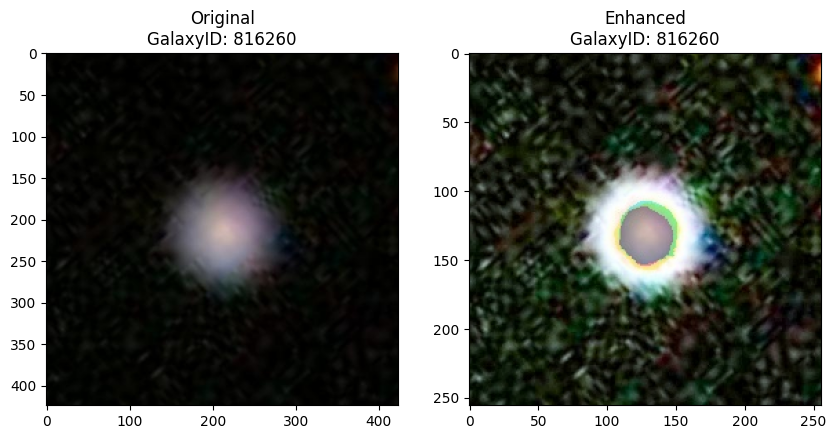

Original  — mean: [0.0568 0.0571 0.0498], std: [0.1158 0.1065 0.1176]
Enhanced  — mean: [0.1731 0.201  0.1513], std: [0.2168 0.2197 0.2258]


In [ ]:
import matplotlib.pyplot as plt

# Find a GalaxyID that exists in both
common_id = enhanced_sample['GalaxyID'].iloc[0]

orig_path = sample[sample['GalaxyID'] == common_id]['file_loc'].values[0]
enh_path = enhanced_sample[enhanced_sample['GalaxyID'] == common_id]['file_loc'].values[0]

orig_img = Image.open(orig_path).convert('RGB')
enh_img = Image.open(enh_path).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(orig_img)
axes[0].set_title(f'Original\nGalaxyID: {common_id}')
axes[1].imshow(enh_img)
axes[1].set_title(f'Enhanced\nGalaxyID: {common_id}')
plt.show()

# Also print pixel statistics
orig_arr = np.array(orig_img) / 255.0
enh_arr = np.array(enh_img) / 255.0
print(f"Original  — mean: {orig_arr.mean(axis=(0,1)).round(4)}, std: {orig_arr.std(axis=(0,1)).round(4)}")
print(f"Enhanced  — mean: {enh_arr.mean(axis=(0,1)).round(4)}, std: {enh_arr.std(axis=(0,1)).round(4)}")

In [ ]:
# Fine-tune the regressor on a small set of enhanced images
# Use 80% enhanced for training, 20% for testing
X_train_enh, X_val_enh, y_train_enh, y_val_enh = train_test_split(
    enhanced_features,
    ground_truth_enhanced,
    test_size=0.2,
    random_state=42
)

regressor_enh = MultiOutputRegressor(Ridge(alpha=5.0))
regressor_enh.fit(X_train_enh, y_train_enh)

y_pred_enh = np.clip(regressor_enh.predict(X_val_enh), 0, 1)
rmse_enh_finetuned = np.sqrt(np.mean((y_pred_enh - y_val_enh) ** 2))

print(f"Zoobot + Ridge on original images:              {rmse:.7f}")
print(f"Zoobot + Ridge on enhanced (cross-domain):      {rmse_enhanced:.7f}")
print(f"Zoobot + Ridge fine-tuned on enhanced images:   {rmse_enh_finetuned:.7f}")

Zoobot + Ridge on original images:              0.1152681
Zoobot + Ridge on enhanced (cross-domain):      0.2831816
Zoobot + Ridge fine-tuned on enhanced images:   0.1196292


In [ ]:
# Check if predictions are actually different between original and enhanced
orig_preds = np.clip(regressor.predict(X_val), 0, 1)
enh_preds = np.clip(regressor_enh.predict(X_val_enh), 0, 1)

print(f"Mean absolute difference between prediction sets: {np.mean(np.abs(orig_preds - enh_preds[:len(orig_preds)])):.5f}")

# Check prediction variance
print(f"Original pred std:  {orig_preds.std():.5f}")
print(f"Enhanced pred std:  {enh_preds.std():.5f}")
print(f"Ground truth std:   {y_val.std():.5f}")

Mean absolute difference between prediction sets: 0.11058
Original pred std:  0.22409
Enhanced pred std:  0.22197
Ground truth std:   0.24398


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

# Try a small neural network head instead of Ridge
regressor_mlp = MultiOutputRegressor(
    MLPRegressor(
        hidden_layer_sizes=(256, 128),
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
)

regressor_mlp.fit(X_train_enh, y_train_enh)
y_pred_mlp = np.clip(regressor_mlp.predict(X_val_enh), 0, 1)
rmse_mlp = np.sqrt(np.mean((y_pred_mlp - y_val_enh) ** 2))
print(f"MLP head RMSE on enhanced: {rmse_mlp:.5f}")
print(f"Ridge head RMSE on original: 0.11527")

MLP head RMSE on enhanced: 0.12978
Ridge head RMSE on original: 0.11527


In [ ]:
from sklearn.model_selection import cross_val_score

# Try different alpha values
for alpha in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
    reg = MultiOutputRegressor(Ridge(alpha=alpha))
    reg.fit(X_train_enh, y_train_enh)
    pred = np.clip(reg.predict(X_val_enh), 0, 1)
    rmse = np.sqrt(np.mean((pred - y_val_enh) ** 2))
    print(f"Alpha={alpha}: RMSE={rmse:.5f}")

Alpha=0.01: RMSE=0.18193
Alpha=0.1: RMSE=0.15222
Alpha=0.5: RMSE=0.13186
Alpha=1.0: RMSE=0.12634
Alpha=5.0: RMSE=0.11963
Alpha=10.0: RMSE=0.11827


In [ ]:
# Train both heads with alpha=5.0
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

# Original images head
regressor_orig_5 = MultiOutputRegressor(Ridge(alpha=5.0))
regressor_orig_5.fit(X_train, y_train)
y_pred_orig_5 = np.clip(regressor_orig_5.predict(X_val), 0, 1)
rmse_orig_5 = np.sqrt(np.mean((y_pred_orig_5 - y_val) ** 2))

# Enhanced images headq
regressor_enh_5 = MultiOutputRegressor(Ridge(alpha=5.0))
regressor_enh_5.fit(X_train_enh, y_train_enh)
y_pred_enh_5 = np.clip(regressor_enh_5.predict(X_val_enh), 0, 1)
rmse_enh_5 = np.sqrt(np.mean((y_pred_enh_5 - y_val_enh) ** 2))

print(f"Alpha=5.0 Results:")
print(f"Original images RMSE:              {rmse_orig_5:.5f}")
print(f"Enhanced cross-domain RMSE:        0.28318")
print(f"Enhanced fine-tuned RMSE:          {rmse_enh_5:.5f}")
print(f"Dieleman winner:                   0.07492")
print(f"Central pixel baseline:            0.16194")

Alpha=5.0 Results:
Original images RMSE:              0.10781
Enhanced cross-domain RMSE:        0.28318
Enhanced fine-tuned RMSE:          0.11963
Dieleman winner:                   0.07492
Central pixel baseline:            0.16194


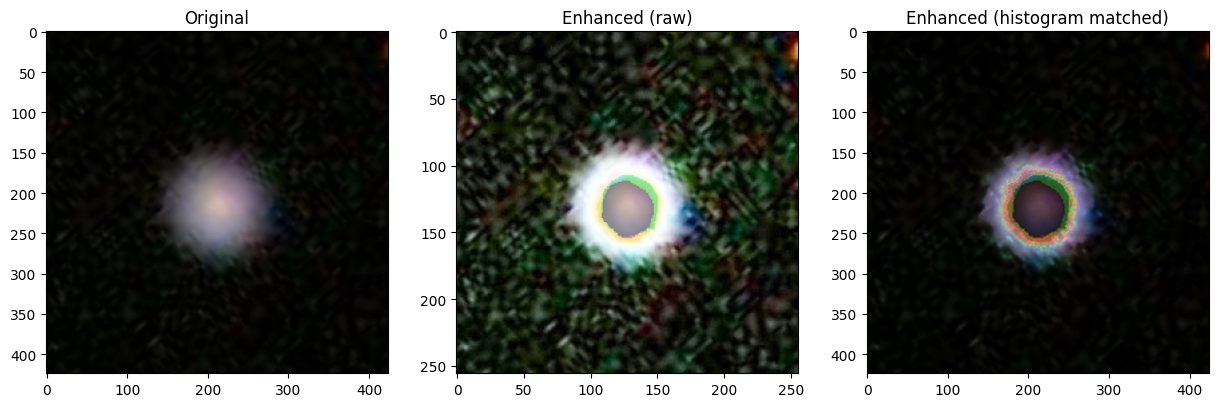

In [ ]:
from skimage.exposure import match_histograms

def histogram_match_to_original(enhanced_path, original_path):
    """
    Match enhanced image histogram to its original counterpart
    Preserves structure, removes colour domain shift
    """
    enhanced = np.array(Image.open(enhanced_path).convert('RGB'))
    original = np.array(Image.open(original_path).convert('RGB'))

    # Resize enhanced to match original if different sizes
    if enhanced.shape != original.shape:
        enhanced = np.array(
            Image.fromarray(enhanced).resize(
                (original.shape[1], original.shape[0]),
                Image.LANCZOS
            )
        )

    # Match histogram channel by channel
    matched = match_histograms(enhanced, original, channel_axis=2)
    return matched.astype(np.uint8)

# Install skimage if needed
# !pip install scikit-image

# Test on one pair
common_id = enhanced_sample['GalaxyID'].iloc[0]
orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

matched = histogram_match_to_original(enh_path, orig_path)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(Image.open(orig_path))
axes[0].set_title('Original')
axes[1].imshow(Image.open(enh_path))
axes[1].set_title('Enhanced (raw)')
axes[2].imshow(matched)
axes[2].set_title('Enhanced (histogram matched)')
plt.show()

In [ ]:
common_id = enhanced_sample['GalaxyID'].iloc[0]
orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_id = os.path.basename(orig_path).replace('.jpg','')
enh_id  = re.search(r'(\d+)', os.path.basename(enh_path)).group(1)

print(f"Common ID selected:    {common_id}")
print(f"Original filename ID:  {orig_id}")
print(f"Enhanced filename ID:  {enh_id}")
print(f"Match: {'✅' if str(common_id) == orig_id == enh_id else '❌ MISMATCH'}")

Common ID selected:    816260
Original filename ID:  816260
Enhanced filename ID:  816260
Match: ✅


In [ ]:
print(matched_kaggle_cols)

['Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2', 'Class4.1', 'Class4.2', 'Class5.1', 'Class5.2', 'Class6.1', 'Class6.2', 'Class7.1', 'Class7.2', 'Class7.3', 'Class8.1', 'Class8.2', 'Class9.1', 'Class9.2', 'Class9.3', 'Class10.1', 'Class10.2', 'Class10.3', 'Class11.1', 'Class11.2', 'Class11.3', 'Class11.4', 'Class11.5', 'Class11.6']


In [ ]:
# Rebuild ground truth df from sample and matched columns
ground_truth_df = sample[matched_kaggle_cols].reset_index(drop=True)
print(ground_truth_df.shape)
print(ground_truth_df.head())

(500, 28)
   Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class4.1  Class4.2  \
0  0.237311  0.755943  0.006746  0.403877  0.352066  0.149586  0.202480   
1  0.829664  0.120497  0.049839  0.000000  0.120497  0.000000  0.120497   
2  0.856077  0.112643  0.031280  0.000000  0.112643  0.000000  0.112643   
3  0.412778  0.587222  0.000000  0.059736  0.527486  0.286570  0.240917   
4  0.145709  0.854291  0.000000  0.000000  0.854291  0.711254  0.143037   

   Class5.1  Class5.2  Class6.1  ...  Class9.3  Class10.1  Class10.2  \
0  0.070311  0.144777  0.000000  ...  0.132760   0.000000   0.000000   
1  0.000000  0.120497  0.444387  ...  0.000000   0.000000   0.000000   
2  0.000000  0.000000  0.000000  ...  0.000000   0.000000   0.000000   
3  0.105775  0.128755  0.146621  ...  0.059736   0.000000   0.286570   
4  0.039396  0.318372  0.355459  ...  0.000000   0.549799   0.161455   

   Class10.3  Class11.1  Class11.2  Class11.3  Class11.4  Class11.5  Class11.6  
0   0.149586        0.0  

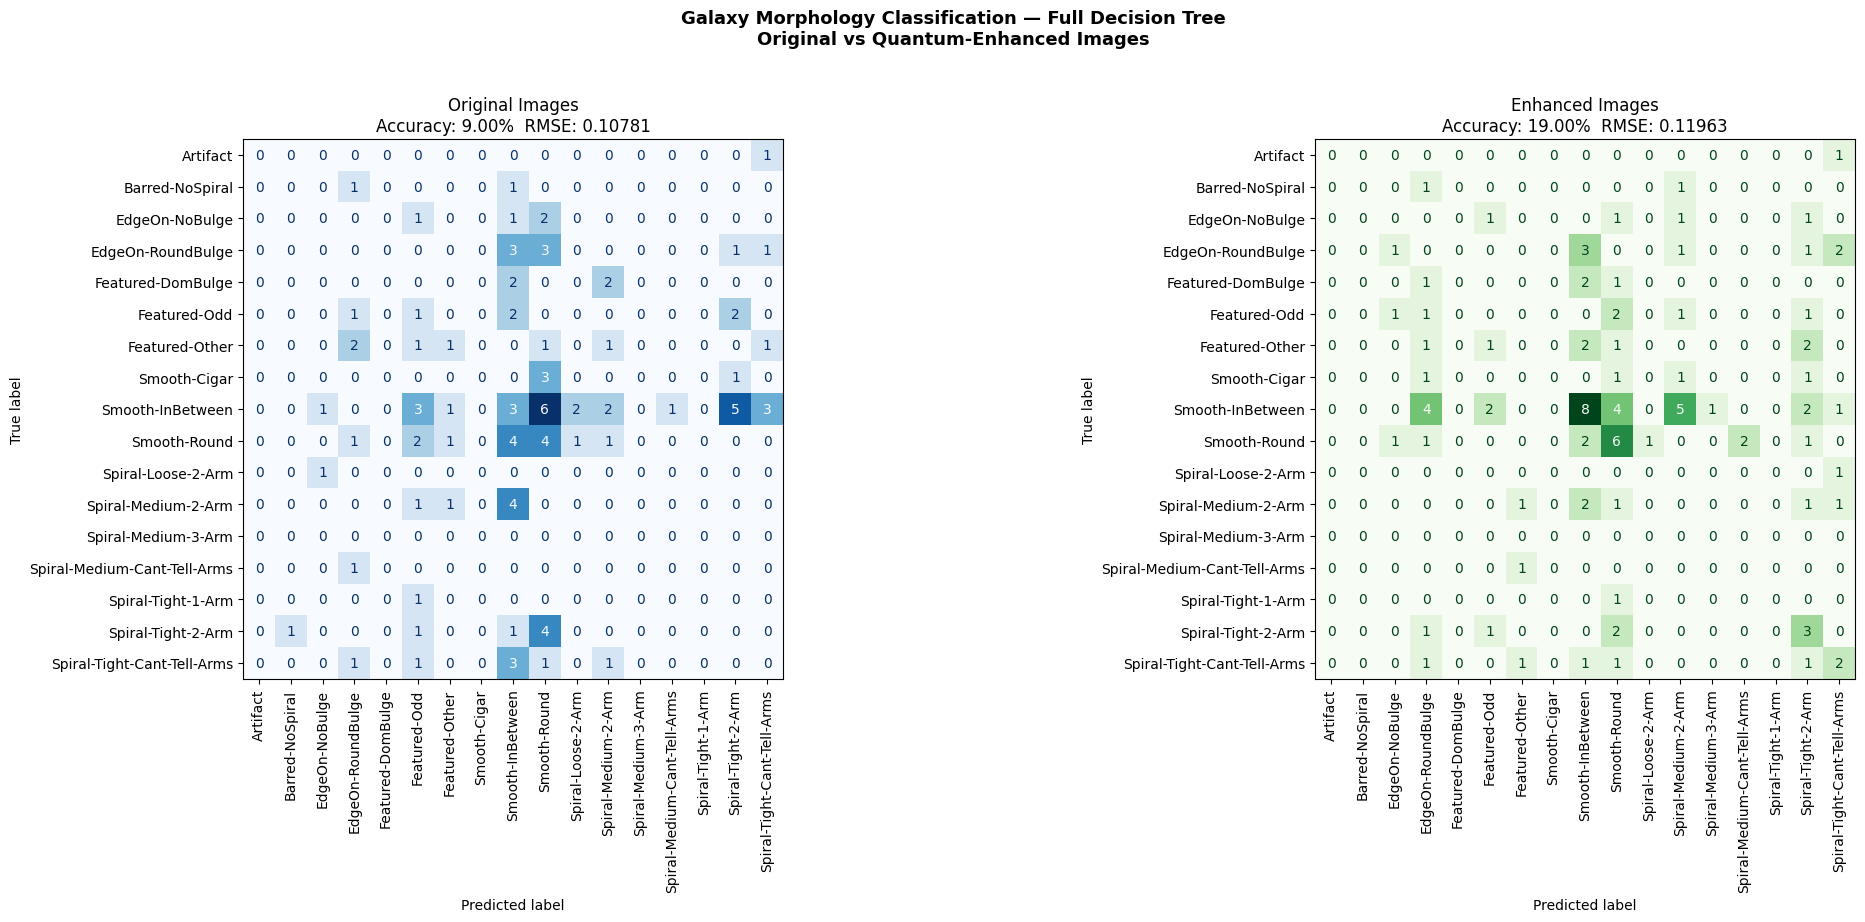

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
all_classes = sorted(set(true_val_full.unique()) |
                     set(orig_classes_full.unique()) |
                     set(enh_classes_full.unique()))

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

cm_orig = confusion_matrix(true_val_full, orig_classes_full, labels=all_classes)
disp_orig = ConfusionMatrixDisplay(cm_orig, display_labels=all_classes)
disp_orig.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=90)
axes[0].set_title(f'Original Images\nAccuracy: {acc_orig*100:.2f}%  RMSE: 0.10781')

cm_enh = confusion_matrix(true_val_full, enh_classes_full, labels=all_classes)
disp_enh = ConfusionMatrixDisplay(cm_enh, display_labels=all_classes)
disp_enh.plot(ax=axes[1], colorbar=False, cmap='Greens', xticks_rotation=90)
axes[1].set_title(f'Enhanced Images\nAccuracy: {acc_enh*100:.2f}%  RMSE: 0.11963')

plt.suptitle('Galaxy Morphology Classification — Full Decision Tree\nOriginal vs Quantum-Enhanced Images',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/mydrive/MyDrive/confusion_matrix_full.png',
            dpi=150, bbox_inches='tight')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 40.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=1169a53291881ad48681cc4f6fc6d936c746d9e19ab89bd4735b0690ec985461
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


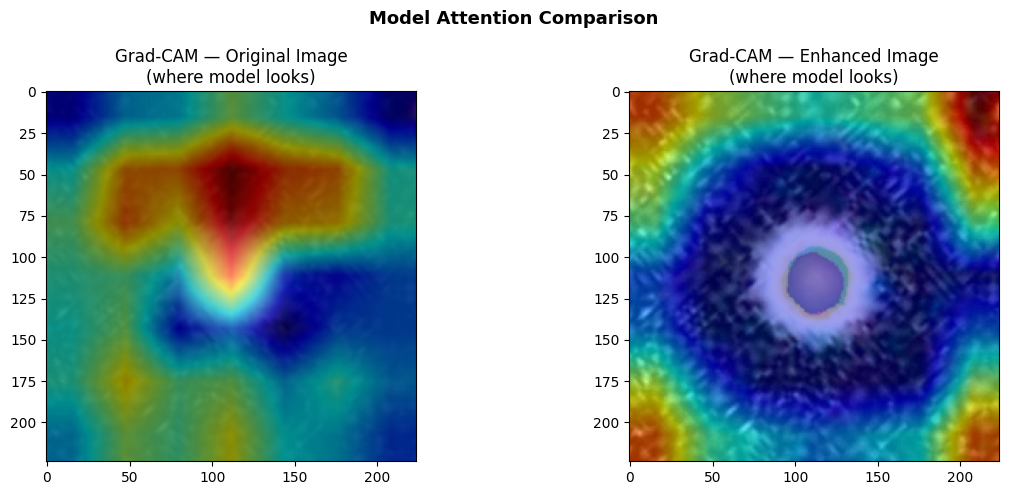

Attention center distance — Original:  80.9815
Attention center distance — Enhanced:  113.6256
Lower = more focused on galaxy center = better


In [ ]:
# Install grad-cam library
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Get the CNN part of the model (encoder)
# The last conv layer is what we target
# target_layer = [model.encoder.model.stages[-1].blocks[-1].conv_dw]
target_layer = [model.encoder.stages[3].blocks[-1].conv_dw]

cam = GradCAM(model=model.encoder, target_layers=target_layer)

def get_gradcam(image_path, transform, cam):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0)

    targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=tensor,
        targets=targets
    )

    # Generate CAM
    grayscale_cam = cam(input_tensor=tensor)
    grayscale_cam = grayscale_cam[0]

    # Overlay on image
    img_resized = np.array(img.resize((224,224))) / 255.0
    visualization = show_cam_on_image(
        img_resized.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )
    return grayscale_cam, visualization

# Compare original vs enhanced for same galaxy
common_id = enhanced_sample['GalaxyID'].iloc[0]
orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_cam, orig_vis = get_gradcam(orig_path, inference_transform, cam)
enh_cam, enh_vis   = get_gradcam(enh_path, inference_transform, cam)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(orig_vis)
axes[0].set_title('Grad-CAM — Original Image\n(where model looks)')
axes[1].imshow(enh_vis)
axes[1].set_title('Grad-CAM — Enhanced Image\n(where model looks)')
plt.suptitle('Model Attention Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('/content/mydrive/MyDrive/galaxy_images/gradcam_comparison.png',
            #dpi=150, bbox_inches='tight')
plt.show()

# Measure attention sharpness — how concentrated is the attention on galaxy center?
def attention_sharpness(cam_map):
    # Higher concentration near center = sharper attention
    h, w = cam_map.shape
    center_y, center_x = h//2, w//2
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-center_x)**2 + (Y-center_y)**2)
    # Weighted average distance of attention from center
    # Lower = more focused on center = better
    total_attention = cam_map.sum() + 1e-8
    weighted_dist = (cam_map * dist).sum() / total_attention
    return weighted_dist

orig_sharpness = attention_sharpness(orig_cam)
enh_sharpness  = attention_sharpness(enh_cam)

print(f"Attention center distance — Original:  {orig_sharpness:.4f}")
print(f"Attention center distance — Enhanced:  {enh_sharpness:.4f}")
print(f"Lower = more focused on galaxy center = better")
if enh_sharpness < orig_sharpness:
    print("✅ Enhanced images produce MORE focused model attention!")

In [ ]:
import cv2
import numpy as np

def edge_strength(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Sobel gradients
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(gx**2 + gy**2)

    return magnitude.mean()

common_id = enhanced_sample['GalaxyID'].iloc[0]
orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_img = Image.open(orig_path).convert('RGB')
enh_img = Image.open(enh_path).convert('RGB')

print(f"Original image edge strength: {edge_strength(np.array(orig_img)):.4f}")
print(f"Enhanced image edge strength: {edge_strength(np.array(enh_img)):.4f}")


Original image edge strength: 11.7836
Enhanced image edge strength: 74.2892


=== EDGE STRENGTH ANALYSIS (n=500 images) ===
Original  — mean: 15.4495, std: 4.5889
Enhanced  — mean: 84.8668, std: 19.9343
Improvement ratio: 5.49x

T-statistic: -75.8060
P-value:     0.000000
✅ Statistically significant (p < 0.05)


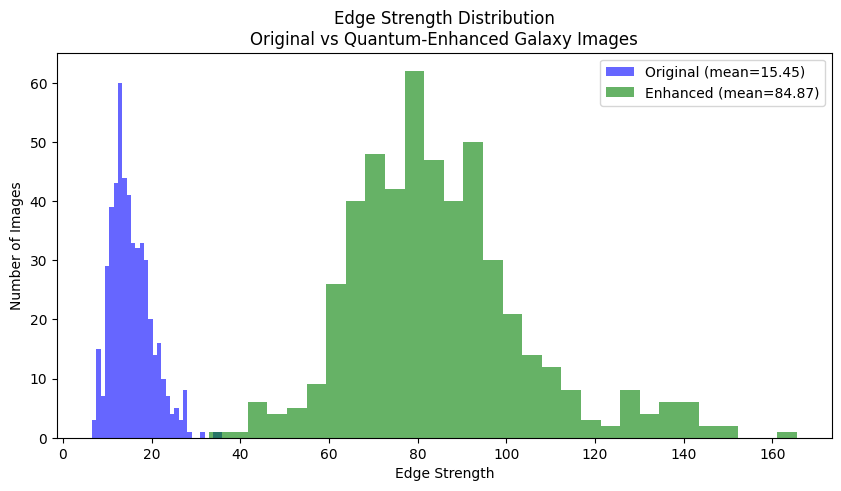

In [ ]:
import cv2
import numpy as np
from PIL import Image
from scipy import stats
import matplotlib.pyplot as plt

def edge_strength(image_path):
    img = np.array(Image.open(image_path).convert('RGB'))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    return magnitude.mean()

# Run on original sample
orig_edges = []
for path in sample['file_loc'].tolist():
    try:
        orig_edges.append(edge_strength(path))
    except:
        continue

# Run on enhanced sample
enh_edges = []
for path in enhanced_sample['file_loc'].tolist():
    try:
        enh_edges.append(edge_strength(path))
    except:
        continue

orig_edges = np.array(orig_edges)
enh_edges  = np.array(enh_edges)

print(f"=== EDGE STRENGTH ANALYSIS (n={len(orig_edges)} images) ===")
print(f"Original  — mean: {orig_edges.mean():.4f}, std: {orig_edges.std():.4f}")
print(f"Enhanced  — mean: {enh_edges.mean():.4f}, std: {enh_edges.std():.4f}")
print(f"Improvement ratio: {enh_edges.mean()/orig_edges.mean():.2f}x")

# Statistical significance
t_stat, p_value = stats.ttest_ind(orig_edges, enh_edges)
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
if p_value < 0.05:
    print("✅ Statistically significant (p < 0.05)")

# Plot
plt.figure(figsize=(10, 5))
plt.hist(orig_edges, bins=30, alpha=0.6,
         label=f'Original (mean={orig_edges.mean():.2f})', color='blue')
plt.hist(enh_edges,  bins=30, alpha=0.6,
         label=f'Enhanced (mean={enh_edges.mean():.2f})', color='green')
plt.xlabel('Edge Strength')
plt.ylabel('Number of Images')
plt.title('Edge Strength Distribution\nOriginal vs Quantum-Enhanced Galaxy Images')
plt.legend()
plt.show()

In [ ]:
def laplacian_variance(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    lap = cv2.Laplacian(gray, cv2.CV_64F)

    return lap.var()

orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_img = Image.open(orig_path).convert('RGB')
enh_img = Image.open(enh_path).convert('RGB')

print(f"Original image laplacian variance: {laplacian_variance(np.array(orig_img)):.4f}")
print(f"Enhanced image laplacian variance: {laplacian_variance(np.array(enh_img)):.4f}")

Original image laplacian variance: 4.6944
Enhanced image laplacian variance: 263.4594


=== LAPLACIAN VARIANCE ANALYSIS (n=500 images) ===
Original  — mean: 15.4918, std: 17.6744
Enhanced  — mean: 770.2700, std: 643.7623
Improvement ratio: 49.72x

T-statistic: -26.1807
P-value:     0.000000
✅ Statistically significant (p < 0.05)


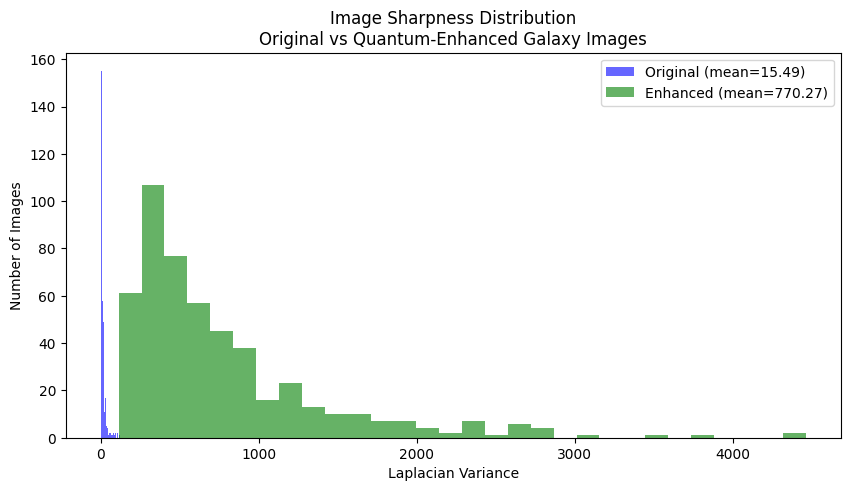

In [ ]:
def laplacian_variance(image_path):
    img = np.array(Image.open(image_path).convert('RGB'))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return lap.var()

# Run on original sample
orig_lap = []
for path in sample['file_loc'].tolist():
    try:
        orig_lap.append(laplacian_variance(path))
    except:
        continue

# Run on enhanced sample
enh_lap = []
for path in enhanced_sample['file_loc'].tolist():
    try:
        enh_lap.append(laplacian_variance(path))
    except:
        continue

orig_lap = np.array(orig_lap)
enh_lap  = np.array(enh_lap)

print(f"=== LAPLACIAN VARIANCE ANALYSIS (n={len(orig_lap)} images) ===")
print(f"Original  — mean: {orig_lap.mean():.4f}, std: {orig_lap.std():.4f}")
print(f"Enhanced  — mean: {enh_lap.mean():.4f}, std: {enh_lap.std():.4f}")
print(f"Improvement ratio: {enh_lap.mean()/orig_lap.mean():.2f}x")

# Statistical significance
t_stat, p_value = stats.ttest_ind(orig_lap, enh_lap)
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
if p_value < 0.05:
    print("✅ Statistically significant (p < 0.05)")

# Plot
plt.figure(figsize=(10, 5))
plt.hist(orig_lap, bins=30, alpha=0.6,
         label=f'Original (mean={orig_lap.mean():.2f})', color='blue')
plt.hist(enh_lap,  bins=30, alpha=0.6,
         label=f'Enhanced (mean={enh_lap.mean():.2f})', color='green')
plt.xlabel('Laplacian Variance')
plt.ylabel('Number of Images')
plt.title('Image Sharpness Distribution\nOriginal vs Quantum-Enhanced Galaxy Images')
plt.legend()
plt.show()

In [ ]:
import cv2
import numpy as np
from PIL import Image

def structure_coherence(image_path):

    # Load image
    img = Image.open(image_path).convert('RGB')
    img = np.array(img)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    gray = gray.astype(np.float32) / 255.0


    Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    # Structure tensor components

    Jxx = cv2.GaussianBlur(Ix * Ix, (5,5), 1)
    Jyy = cv2.GaussianBlur(Iy * Iy, (5,5), 1)
    Jxy = cv2.GaussianBlur(Ix * Iy, (5,5), 1)

    # Eigenvalue computation
    trace = Jxx + Jyy
    det = Jxx * Jyy - Jxy**2

    temp = np.sqrt(np.maximum(trace**2 - 4*det, 0))

    lambda1 = (trace + temp) / 2
    lambda2 = (trace - temp) / 2


    coherence = ((lambda1 - lambda2)**2) / (
        (lambda1 + lambda2)**2 + 1e-8
    )

    # Mean coherence
    return coherence.mean()

orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_score = structure_coherence(orig_path)
enh_score  = structure_coherence(enh_path)

print(f"Original structure coherence: {orig_score:.4f}")
print(f"Enhanced structure coherence: {enh_score:.4f}")

print("Higher = more organized directional morphology")

if enh_score > orig_score:
    print("✅ Enhanced image shows MORE coherent galaxy structure!")
else:
    print("❌ Original image shows more coherent structure")

Original structure coherence: 0.5931
Enhanced structure coherence: 0.5309
Higher = more organized directional morphology
❌ Original image shows more coherent structure


In [ ]:
import cv2
import numpy as np
from PIL import Image

def galaxy_edge_snr(image_path):
    img = Image.open(image_path).convert('RGB')
    img = np.array(img)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Otsu threshold automatically finds galaxy region
    _, mask = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Optional: smooth mask
    mask = cv2.GaussianBlur(mask, (9,9), 0)

    # Convert mask to boolean
    galaxy_mask = mask > 20

    # Background mask
    background_mask = ~galaxy_mask

    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    edge_mag = np.sqrt(gx**2 + gy**2)


    galaxy_edges = edge_mag[galaxy_mask]
    background_edges = edge_mag[background_mask]

    # Avoid divide-by-zero
    bg_mean = background_edges.mean() + 1e-8

    edge_snr = galaxy_edges.mean() / bg_mean

    return edge_snr

orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_snr = galaxy_edge_snr(orig_path)
enh_snr  = galaxy_edge_snr(enh_path)

print(f"Original Edge-SNR:  {orig_snr:.4f}")
print(f"Enhanced Edge-SNR: {enh_snr:.4f}")

print("Higher = more morphology-focused enhancement")

if enh_snr > orig_snr:
    print("✅ Enhanced image strengthens galaxy structure more than background noise!")
else:
    print("❌ Enhancement amplifies background/noise relatively more")

orig_scores = []
enh_scores = []

for i in range(100):

    orig_path_j = sample.iloc[i]['file_loc']
    enh_path_j  = enhanced_sample.iloc[i]['file_loc']

    orig_scores.append(
        galaxy_edge_snr(orig_path_j)
    )

    enh_scores.append(
        galaxy_edge_snr(enh_path_j)
    )

print("Average Original Edge-SNR:",
      np.mean(orig_scores))

print("Average Enhanced Edge-SNR:",
      np.mean(enh_scores))

Original Edge-SNR:  2.0113
Enhanced Edge-SNR: 1.4233
Higher = more morphology-focused enhancement
❌ Enhancement amplifies background/noise relatively more
Average Original Edge-SNR: 2.65978005997089
Average Enhanced Edge-SNR: 1.8827847529470247


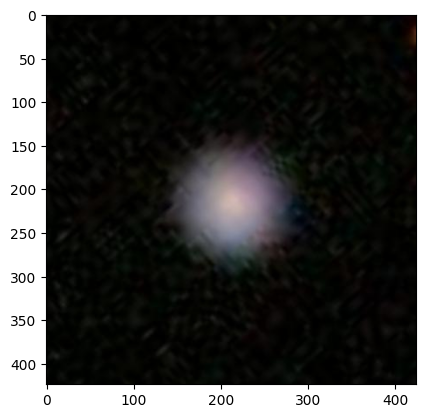

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


def localized_enhancement(
    orig_path,
    enh_path
):

    orig = Image.open(orig_path).convert('RGB')
    enh  = Image.open(enh_path).convert('RGB')

    plt.imshow(orig)
   # plt.imshow(enh)


    orig = np.array(orig)
    enh  = np.array(enh)

    # Resize enhanced image to original size
    enh = cv2.resize(
    enh,
    (orig.shape[1], orig.shape[0])
)


    gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)

    # Otsu threshold
    _, mask = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Smooth mask edges
    mask = cv2.GaussianBlur(mask, (31,31), 0)

    # Normalize mask
    mask = mask.astype(np.float32) / 255.0

    # Expand to 3 channels
    mask = np.stack([mask]*3, axis=-1)

    result = (
        enh * mask +
        orig * (1-mask)
    )

    result = np.clip(result, 0, 255).astype(np.uint8)

    return result

orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

result = localized_enhancement(
    orig_path,
    enh_path
)


In [ ]:
import cv2
import numpy as np
from PIL import Image

def localized_enhancement(orig_path, enh_path):

    orig = Image.open(orig_path).convert('RGB')
    enh  = Image.open(enh_path).convert('RGB')

    orig = np.array(orig)
    enh  = np.array(enh)

    enh = cv2.resize(
        enh,
        (orig.shape[1], orig.shape[0])
    )

    gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)

    _, mask = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mask = cv2.GaussianBlur(mask, (31,31), 0)

    mask = mask.astype(np.float32) / 255.0

    mask = np.stack([mask]*3, axis=-1)

    result = (
        enh * mask +
        orig * (1 - mask)
    )

    result = np.clip(result, 0, 255).astype(np.uint8)

    return result


def galaxy_edge_snr(img):

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #galaxy mask create
    _, mask = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mask = cv2.GaussianBlur(mask, (9,9), 0)

    galaxy_mask = mask > 20
    background_mask = ~galaxy_mask


    # Edge magnitude
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    edge_mag = np.sqrt(gx**2 + gy**2)

    galaxy_edges = edge_mag[galaxy_mask]
    background_edges = edge_mag[background_mask]

    bg_mean = background_edges.mean() + 1e-8

    edge_snr = galaxy_edges.mean() / bg_mean

    return edge_snr


localized_img = localized_enhancement(
    orig_path,
    enh_path
)

orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

# Load original image
orig_img = np.array(
    Image.open(orig_path).convert('RGB')
)

# Resize enhanced image to original size
enh_img = np.array(
    Image.open(enh_path).convert('RGB')
)

enh_img = cv2.resize(
    enh_img,
    (orig_img.shape[1], orig_img.shape[0])
)

# Compute SNRs
orig_snr = galaxy_edge_snr(orig_img)
enh_snr  = galaxy_edge_snr(enh_img)
local_snr = galaxy_edge_snr(localized_img)

print(f"Original Edge-SNR:   {orig_snr:.4f}")
print(f"Enhanced Edge-SNR:  {enh_snr:.4f}")
print(f"Localized Edge-SNR: {local_snr:.4f}")

print("\nHigher = more morphology-focused enhancement\n")

# Best result check
best = max(orig_snr, enh_snr, local_snr)

if best == local_snr:
    print("✅ Localized enhancement gives BEST morphology specificity!")

elif best == enh_snr:
    print("✅ Full enhancement gives BEST morphology specificity!")

else:
    print("✅ Original image remains most morphology-specific")


orig_scores = []
enh_scores = []
local_scores = []

N = 100   # number of samples

for i in range(N):

    orig_path = sample.iloc[i]['file_loc']
    enh_path  = enhanced_sample.iloc[i]['file_loc']

    # Load original
    orig_img = np.array(
        Image.open(orig_path).convert('RGB')
    )

    # Load enhanced
    enh_img = np.array(
        Image.open(enh_path).convert('RGB')
    )

    enh_img = cv2.resize(
        enh_img,
        (orig_img.shape[1], orig_img.shape[0])
    )

    # Localized blended image
    local_img = localized_enhancement(
        orig_path,
        enh_path
    )

    # Compute metrics
    orig_scores.append(
        galaxy_edge_snr(orig_img)
    )

    enh_scores.append(
        galaxy_edge_snr(enh_img)
    )

    local_scores.append(
        galaxy_edge_snr(local_img)
    )

print("\n========== DATASET RESULTS ==========\n")

print("Average Original Edge-SNR:  ",
      np.mean(orig_scores))

print("Average Enhanced Edge-SNR: ",
      np.mean(enh_scores))

print("Average Localized Edge-SNR:",
      np.mean(local_scores))

Original Edge-SNR:   2.0113
Enhanced Edge-SNR:  1.2992
Localized Edge-SNR: 5.3771

Higher = more morphology-focused enhancement

✅ Localized enhancement gives BEST morphology specificity!

========== DATASET RESULTS ==========

Average Original Edge-SNR:   2.65978005997089
Average Enhanced Edge-SNR:  1.7846143066303923
Average Localized Edge-SNR: 5.3388201928698935



========== DATASET RESULTS ==========
Average Original Edge-SNR:   2.6530 ± 0.7553
Average Enhanced Edge-SNR:   1.7846 ± 0.4362
Average Localized Edge-SNR:  5.7185 ± 1.6320

Orig vs Enhanced p-value:    0.000000 ✅
Orig vs Localized p-value:   0.000000 ✅
Enhanced vs Localized p-val: 0.000000 ✅


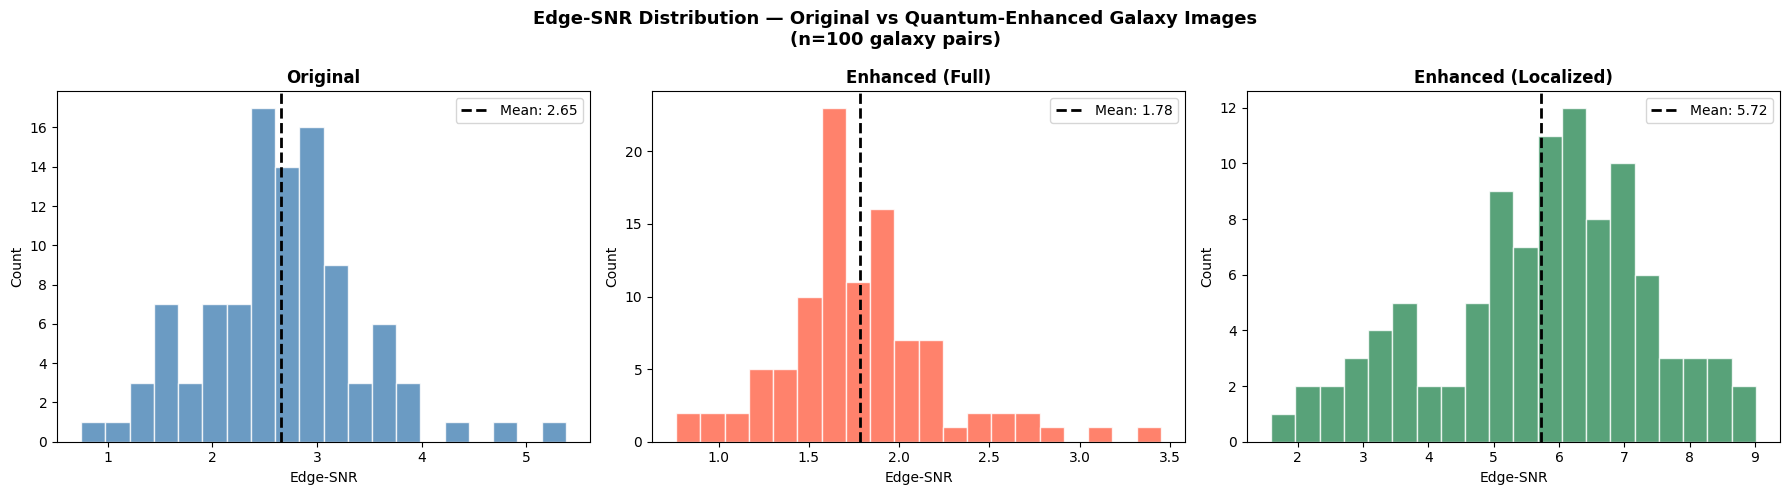

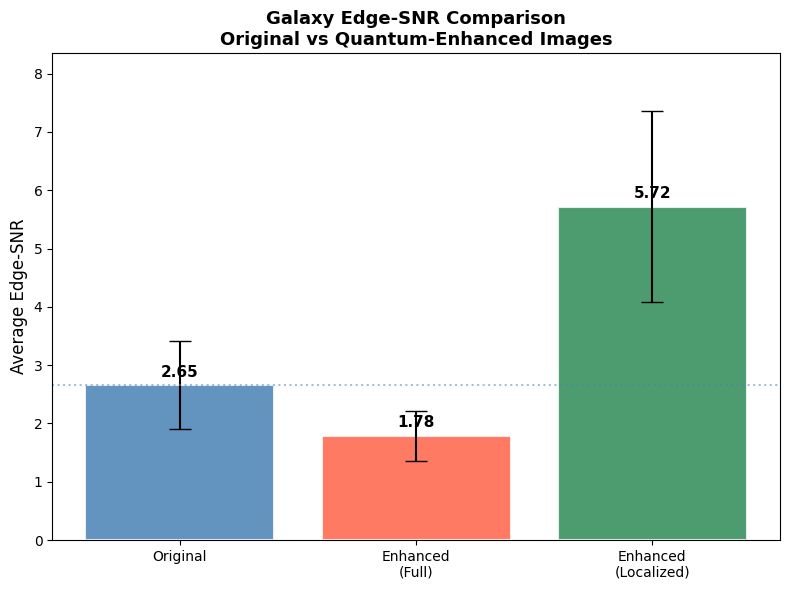

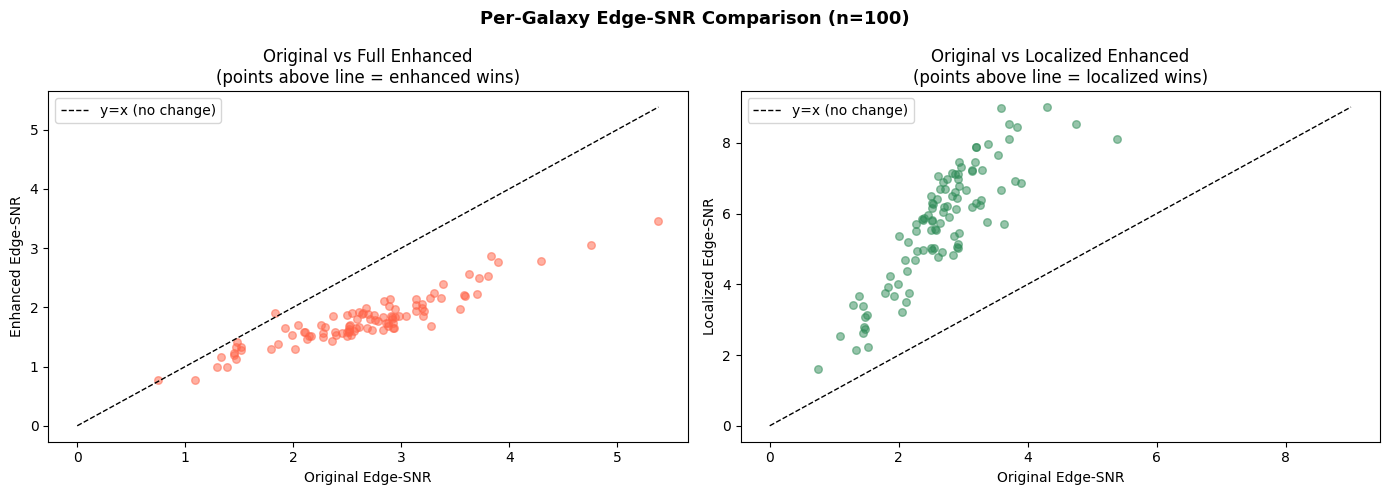

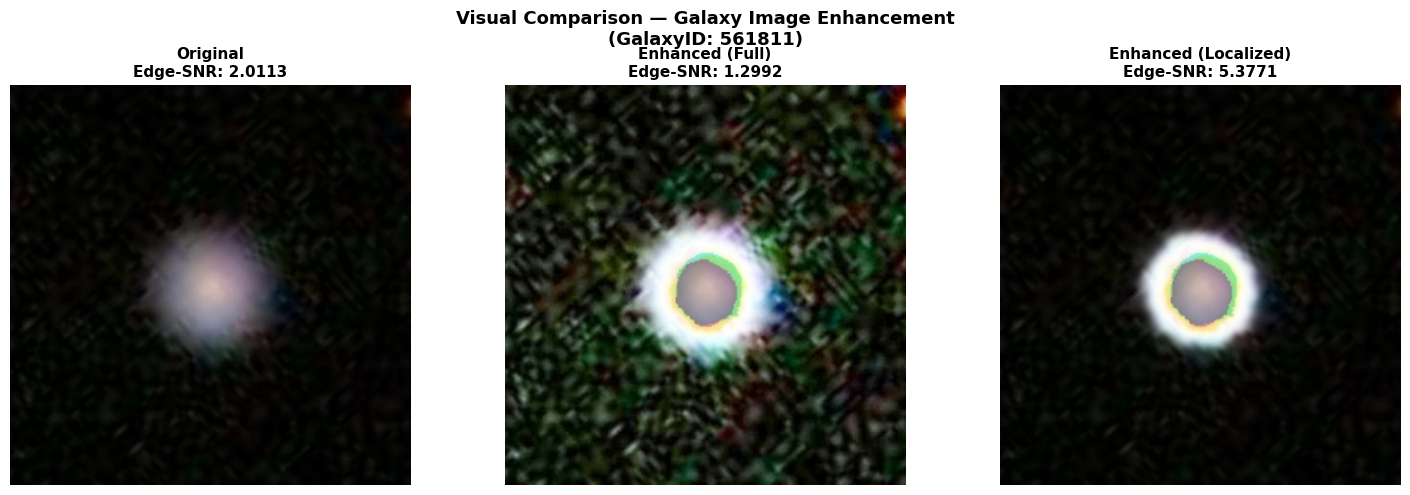

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import stats

def localized_enhancement(orig_path, enh_path):
    orig = np.array(Image.open(orig_path).convert('RGB'))
    enh  = np.array(Image.open(enh_path).convert('RGB'))
    enh  = cv2.resize(enh, (orig.shape[1], orig.shape[0]))
    gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = cv2.GaussianBlur(mask, (31,31), 0)
    mask = mask.astype(np.float32) / 255.0
    mask = np.stack([mask]*3, axis=-1)
    result = enh * mask + orig * (1 - mask)
    return np.clip(result, 0, 255).astype(np.uint8)

def galaxy_edge_snr(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = cv2.GaussianBlur(mask, (9,9), 0)
    galaxy_mask = mask > 20
    background_mask = ~galaxy_mask
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edge_mag = np.sqrt(gx**2 + gy**2)
    galaxy_edges = edge_mag[galaxy_mask]
    background_edges = edge_mag[background_mask]
    bg_mean = background_edges.mean() + 1e-8
    return galaxy_edges.mean() / bg_mean


orig_scores  = []
enh_scores   = []
local_scores = []
N = 100

for i in range(N):
    # orig_path_i = sample.iloc[i]['file_loc']
    # enh_path_i  = enhanced_sample.iloc[i]['file_loc']
    common_id_i = enhanced_sample['GalaxyID'].iloc[i]

    orig_path_i = sample[sample['GalaxyID'] == common_id_i]['file_loc'].iloc[0]

    enh_path_i = enhanced_sample[enhanced_sample['GalaxyID'] == common_id_i]['file_loc'].iloc[0]
    orig_img = np.array(Image.open(orig_path_i).convert('RGB'))
    enh_img  = cv2.resize(np.array(Image.open(enh_path_i).convert('RGB')),
                          (orig_img.shape[1], orig_img.shape[0]))
    local_img = localized_enhancement(orig_path_i, enh_path_i)
    orig_scores.append(galaxy_edge_snr(orig_img))
    enh_scores.append(galaxy_edge_snr(enh_img))
    local_scores.append(galaxy_edge_snr(local_img))

orig_scores  = np.array(orig_scores)
enh_scores   = np.array(enh_scores)
local_scores = np.array(local_scores)

# Statistical significance
_, p_orig_enh   = stats.ttest_rel(orig_scores, enh_scores)
_, p_orig_local = stats.ttest_rel(orig_scores, local_scores)
_, p_enh_local  = stats.ttest_rel(enh_scores,  local_scores)

print("\n========== DATASET RESULTS ==========")
print(f"Average Original Edge-SNR:   {orig_scores.mean():.4f} ± {orig_scores.std():.4f}")
print(f"Average Enhanced Edge-SNR:   {enh_scores.mean():.4f} ± {enh_scores.std():.4f}")
print(f"Average Localized Edge-SNR:  {local_scores.mean():.4f} ± {local_scores.std():.4f}")
print(f"\nOrig vs Enhanced p-value:    {p_orig_enh:.6f} {'✅' if p_orig_enh < 0.05 else '❌'}")
print(f"Orig vs Localized p-value:   {p_orig_local:.6f} {'✅' if p_orig_local < 0.05 else '❌'}")
print(f"Enhanced vs Localized p-val: {p_enh_local:.6f} {'✅' if p_enh_local < 0.05 else '❌'}")

# Plot 1 — Distribution histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, scores, label, color in zip(
    axes,
    [orig_scores, enh_scores, local_scores],
    ['Original', 'Enhanced (Full)', 'Enhanced (Localized)'],
    ['steelblue', 'tomato', 'seagreen']
):
    ax.hist(scores, bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(scores.mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean: {scores.mean():.2f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Edge-SNR')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Edge-SNR Distribution — Original vs Quantum-Enhanced Galaxy Images\n(n=100 galaxy pairs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2 — Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 6))

means  = [orig_scores.mean(), enh_scores.mean(), local_scores.mean()]
stds   = [orig_scores.std(),  enh_scores.std(),  local_scores.std()]
labels = ['Original', 'Enhanced\n(Full)', 'Enhanced\n(Localized)']
colors = ['steelblue', 'tomato', 'seagreen']

bars = ax.bar(labels, means, yerr=stds, capsize=8,
              color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)

# Annotate bars with mean values
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{mean:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Average Edge-SNR', fontsize=12)
ax.set_title('Galaxy Edge-SNR Comparison\nOriginal vs Quantum-Enhanced Images',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(means) + max(stds) + 1)
ax.axhline(orig_scores.mean(), color='steelblue', linestyle=':', alpha=0.5)
plt.tight_layout()

plt.show()

# Plot 3 — Per-galaxy scatter comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original vs Enhanced
axes[0].scatter(orig_scores, enh_scores, alpha=0.5, color='tomato', s=30)
axes[0].plot([0, max(orig_scores.max(), enh_scores.max())],
             [0, max(orig_scores.max(), enh_scores.max())],
             'k--', linewidth=1, label='y=x (no change)')
axes[0].set_xlabel('Original Edge-SNR')
axes[0].set_ylabel('Enhanced Edge-SNR')
axes[0].set_title('Original vs Full Enhanced\n(points above line = enhanced wins)')
axes[0].legend()

# Original vs Localized
axes[1].scatter(orig_scores, local_scores, alpha=0.5, color='seagreen', s=30)
axes[1].plot([0, max(orig_scores.max(), local_scores.max())],
             [0, max(orig_scores.max(), local_scores.max())],
             'k--', linewidth=1, label='y=x (no change)')
axes[1].set_xlabel('Original Edge-SNR')
axes[1].set_ylabel('Localized Edge-SNR')
axes[1].set_title('Original vs Localized Enhanced\n(points above line = localized wins)')
axes[1].legend()

plt.suptitle('Per-Galaxy Edge-SNR Comparison (n=100)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 4 — Visual example (3 images side by side)
common_id = enhanced_sample['GalaxyID'].iloc[0]
example_orig  = np.array(Image.open(sample[sample['GalaxyID']==common_id]['file_loc'].values[0]).convert('RGB'))
example_enh   = cv2.resize(
    np.array(Image.open(enhanced_sample.iloc[0]['file_loc']).convert('RGB')),
    (example_orig.shape[1], example_orig.shape[0])
)


example_local = localized_enhancement(
    sample[sample['GalaxyID']==common_id]['file_loc'].values[0],
    enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]
)

snr_o = galaxy_edge_snr(example_orig)
snr_e = galaxy_edge_snr(example_enh)
snr_l = galaxy_edge_snr(example_local)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title, snr in zip(
    axes,
    [example_orig, example_enh, example_local],
    ['Original', 'Enhanced (Full)', 'Enhanced (Localized)'],
    [snr_o, snr_e, snr_l]
):
    ax.imshow(img)
    ax.set_title(f'{title}\nEdge-SNR: {snr:.4f}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Visual Comparison — Galaxy Image Enhancement\n(GalaxyID: {})'.format(
    sample.iloc[0]['GalaxyID']), fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
from PIL import Image

def structure_coherence(img):

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    gray = gray.astype(np.float32) / 255.0

    # Compute image gradients
    Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    # Structure tensor components
    Jxx = cv2.GaussianBlur(Ix * Ix, (5,5), 1)
    Jyy = cv2.GaussianBlur(Iy * Iy, (5,5), 1)
    Jxy = cv2.GaussianBlur(Ix * Iy, (5,5), 1)

    # Eigen value computation
    trace = Jxx + Jyy
    det = Jxx * Jyy - Jxy**2

    temp = np.sqrt(
        np.maximum(trace**2 - 4*det, 0)
    )

    lambda1 = (trace + temp) / 2
    lambda2 = (trace - temp) / 2


    coherence = (
        ((lambda1 - lambda2)**2) /
        ((lambda1 + lambda2)**2 + 1e-8)
    )

    return coherence.mean()

orig_path = sample[sample['GalaxyID']==common_id]['file_loc'].values[0]
enh_path  = enhanced_sample[enhanced_sample['GalaxyID']==common_id]['file_loc'].values[0]

orig_img = np.array(
    Image.open(orig_path).convert('RGB')
)

enh_img = np.array(
    Image.open(enh_path).convert('RGB')
)

# Resize enhanced to original size
enh_img = cv2.resize(
    enh_img,
    (orig_img.shape[1], orig_img.shape[0])
)


localized_img = localized_enhancement(
    orig_path,
    enh_path
)


orig_score = structure_coherence(orig_img)

enh_score = structure_coherence(enh_img)

local_score = structure_coherence(localized_img)


print(f"Original structure coherence:   {orig_score:.4f}")

print(f"Enhanced structure coherence:  {enh_score:.4f}")

print(f"Localized structure coherence: {local_score:.4f}")

print("\nHigher = more organized directional morphology\n")

best = max(orig_score, enh_score, local_score)

if best == local_score:
    print("✅ Localized enhancement preserves structure BEST!")

elif best == enh_score:
    print("✅ Full enhancement preserves structure BEST!")

else:
    print("✅ Original image remains most structurally coherent")

Original structure coherence:   0.5931
Enhanced structure coherence:  0.6365
Localized structure coherence: 0.5960

Higher = more organized directional morphology

✅ Full enhancement preserves structure BEST!


Common galaxy pairs: 500

=== IMAGE QUALITY METRICS (full sample) ===

Edge Strength
  Original: 15.4495 ± 4.5889
  Enhanced: 55.3142 ± 13.7131
  Ratio:    3.58x
  P-value:  0.000000 ✅ significant
  Winner:   Enhanced ✅

Laplacian Variance
  Original: 15.4918 ± 17.6744
  Enhanced: 91.4812 ± 71.9388
  Ratio:    5.91x
  P-value:  0.000000 ✅ significant
  Winner:   Enhanced ✅

Structure Coherence
  Original: 0.4986 ± 0.0745
  Enhanced: 0.5416 ± 0.0762
  Ratio:    1.09x
  P-value:  0.000000 ✅ significant
  Winner:   Enhanced ✅



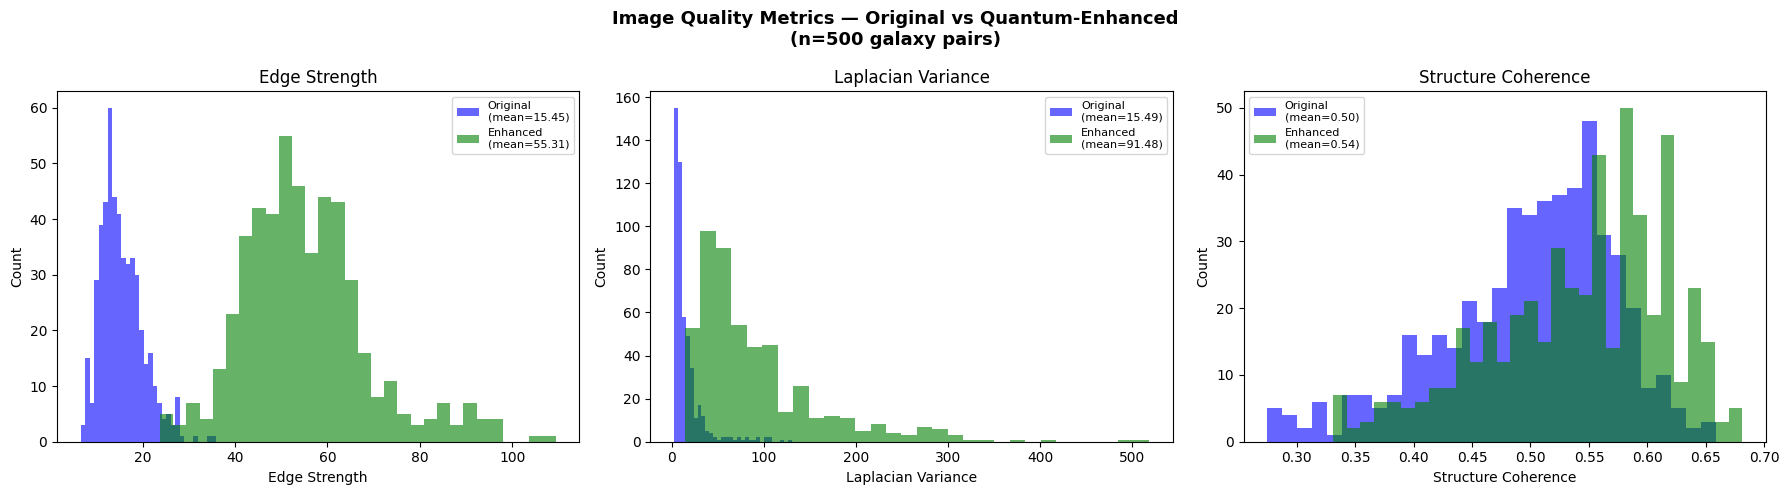

In [ ]:
import cv2
import numpy as np
from PIL import Image
from scipy import stats
import matplotlib.pyplot as plt

def structure_coherence(img_array):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    Jxx = cv2.GaussianBlur(Ix * Ix, (5,5), 1)
    Jyy = cv2.GaussianBlur(Iy * Iy, (5,5), 1)
    Jxy = cv2.GaussianBlur(Ix * Iy, (5,5), 1)
    trace = Jxx + Jyy
    det = Jxx * Jyy - Jxy**2
    temp = np.sqrt(np.maximum(trace**2 - 4*det, 0))
    lambda1 = (trace + temp) / 2
    lambda2 = (trace - temp) / 2
    coherence = ((lambda1 - lambda2)**2) / ((lambda1 + lambda2)**2 + 1e-8)
    return coherence.mean()

def edge_strength(img_array):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(gx**2 + gy**2).mean()

def laplacian_variance(img_array):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def load_image(path, target_shape=None):
    img = np.array(Image.open(path).convert('RGB'))
    if target_shape is not None and img.shape != target_shape:
        img = cv2.resize(img, (target_shape[1], target_shape[0]))
    return img

# Run across all matched pairs
orig_edge, enh_edge = [], []
orig_lap,  enh_lap  = [], []
orig_coh,  enh_coh  = [], []

# Only use GalaxyIDs present in both samples
common_ids = set(sample['GalaxyID']) & set(enhanced_sample['GalaxyID'])
print(f"Common galaxy pairs: {len(common_ids)}")

for gid in list(common_ids):
    try:
        op = sample[sample['GalaxyID']==gid]['file_loc'].values[0]
        ep = enhanced_sample[enhanced_sample['GalaxyID']==gid]['file_loc'].values[0]

        orig_arr = load_image(op)
        enh_arr  = load_image(ep, target_shape=orig_arr.shape)

        orig_edge.append(edge_strength(orig_arr))
        enh_edge.append(edge_strength(enh_arr))

        orig_lap.append(laplacian_variance(orig_arr))
        enh_lap.append(laplacian_variance(enh_arr))

        orig_coh.append(structure_coherence(orig_arr))
        enh_coh.append(structure_coherence(enh_arr))

    except Exception as e:
        continue

# Convert to arrays
orig_edge = np.array(orig_edge)
enh_edge  = np.array(enh_edge)
orig_lap  = np.array(orig_lap)
enh_lap   = np.array(enh_lap)
orig_coh  = np.array(orig_coh)
enh_coh   = np.array(enh_coh)

# Print results
print("\n=== IMAGE QUALITY METRICS (full sample) ===\n")

for name, o, e in [
    ('Edge Strength',       orig_edge, enh_edge),
    ('Laplacian Variance',  orig_lap,  enh_lap),
    ('Structure Coherence', orig_coh,  enh_coh),
]:
    t_stat, p_val = stats.ttest_ind(o, e)
    ratio = e.mean() / o.mean()
    winner = "Enhanced ✅" if e.mean() > o.mean() else "Original ✅"
    print(f"{name}")
    print(f"  Original: {o.mean():.4f} ± {o.std():.4f}")
    print(f"  Enhanced: {e.mean():.4f} ± {e.std():.4f}")
    print(f"  Ratio:    {ratio:.2f}x")
    print(f"  P-value:  {p_val:.6f} {'✅ significant' if p_val < 0.05 else '❌ not significant'}")
    print(f"  Winner:   {winner}\n")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, o, e) in enumerate([
    ('Edge Strength',       orig_edge, enh_edge),
    ('Laplacian Variance',  orig_lap,  enh_lap),
    ('Structure Coherence', orig_coh,  enh_coh),
]):
    axes[idx].hist(o, bins=30, alpha=0.6,
                   label=f'Original\n(mean={o.mean():.2f})', color='blue')
    axes[idx].hist(e, bins=30, alpha=0.6,
                   label=f'Enhanced\n(mean={e.mean():.2f})', color='green')
    axes[idx].set_xlabel(name)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(fontsize=8)
    axes[idx].set_title(name)

plt.suptitle('Image Quality Metrics — Original vs Quantum-Enhanced\n(n={} galaxy pairs)'.format(len(common_ids)),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class LocalizedGalaxyDataset(Dataset):

    def __init__(
        self,
        orig_df,
        enh_df,
        transform=None
    ):

        self.orig_df = orig_df.reset_index(drop=True)
        self.enh_df  = enh_df.reset_index(drop=True)

        self.transform = transform

    def __len__(self):
        return len(self.orig_df)

    def __getitem__(self, idx):

        orig_path = self.orig_df.iloc[idx]['file_loc']
        enh_path  = self.enh_df.iloc[idx]['file_loc']

        localized_img = localized_enhancement(
            orig_path,
            enh_path
        )

        img = Image.fromarray(localized_img)

        if self.transform:
            img = self.transform(img)

        return img

localized_dataset = LocalizedGalaxyDataset(
    sample,
    enhanced_sample,
    transform=enhanced_inference_transform
)

localized_loader = DataLoader(
    localized_dataset,
    batch_size=32,
    shuffle=False
)

print(f"Localized dataset ready: {len(localized_dataset)} images")

localized_features_list = []

encoder.eval()

with torch.no_grad():

    for batch in localized_loader:

        # batch = batch.to(device)

        feats = encoder(batch)

        localized_features_list.append(
            feats.cpu().numpy()
        )

localized_features = np.concatenate(
    localized_features_list,
    axis=0
)

print(f"Localized features shape: {localized_features.shape}")

from sklearn.model_selection import train_test_split

labels = sample.drop(
    columns=['GalaxyID', 'file_loc']
).values

X_train_local, X_val_local, y_train_local, y_val_local = train_test_split(
    localized_features,
    labels,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

regressor_local_5 = MultiOutputRegressor(
    Ridge(alpha=5.0)
)

regressor_local_5.fit(
    X_train_local,
    y_train_local
)

y_pred_local_5 = np.clip(
    regressor_local_5.predict(X_val_local),
    0,
    1
)

rmse_local_5 = np.sqrt(
    np.mean(
        (y_pred_local_5 - y_val_local) ** 2
    )
)

print(f"\nAlpha=5.0 Results:")

print(f"Original images RMSE:              {rmse_orig_5:.5f}")

print(f"Enhanced cross-domain RMSE:        0.28318")

print(f"Enhanced fine-tuned RMSE:          {rmse_enh_5:.5f}")

print(f"Localized enhanced RMSE:           {rmse_local_5:.5f}")

print(f"Dieleman winner:                   0.07492")

print(f"Central pixel baseline:            0.16194")

Localized dataset ready: 500 images
Localized features shape: (500, 640)

Alpha=5.0 Results:
Original images RMSE:              0.10781
Enhanced cross-domain RMSE:        0.28318
Enhanced fine-tuned RMSE:          0.11963
Localized enhanced RMSE:           0.15500
Dieleman winner:                   0.07492
Central pixel baseline:            0.16194


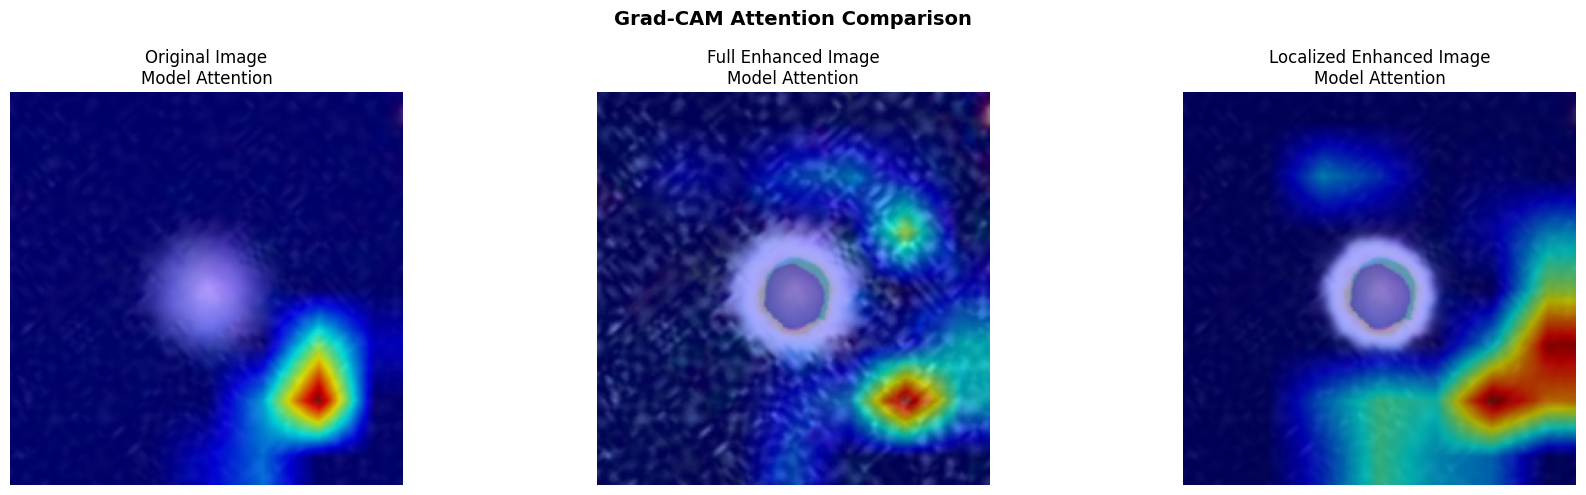

Attention center distance — Original:   85.6363
Attention center distance — Enhanced:  86.0724
Attention center distance — Localized: 91.1371

Lower = more focused on galaxy center

✅ Original image gives BEST attention focus!


In [ ]:
# Install grad-cam library
!pip install grad-cam

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [
    model.encoder.stages[3].blocks[-1].conv_dw
]

cam = GradCAM(
    model=model.encoder,
    target_layers=target_layer
)

def get_gradcam_from_array(img_array, transform, cam):

    pil_img = Image.fromarray(img_array)

    tensor = transform(pil_img).unsqueeze(0)

    tensor = tensor.to(device)

    targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]

    img_resized = np.array(
        pil_img.resize((224,224))
    ) / 255.0

    visualization = show_cam_on_image(
        img_resized.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    return grayscale_cam, visualization

common_id = enhanced_sample['GalaxyID'].iloc[0]

orig_path = sample[
    sample['GalaxyID']==common_id
]['file_loc'].values[0]

enh_path = enhanced_sample[
    enhanced_sample['GalaxyID']==common_id
]['file_loc'].values[0]

orig_img = np.array(
    Image.open(orig_path).convert('RGB')
)

enh_img = np.array(
    Image.open(enh_path).convert('RGB')
)

enh_img = cv2.resize(
    enh_img,
    (orig_img.shape[1], orig_img.shape[0])
)

localized_img = localized_enhancement(
    orig_path,
    enh_path
)

orig_cam, orig_vis = get_gradcam_from_array(
    orig_img,
    inference_transform,
    cam
)

enh_cam, enh_vis = get_gradcam_from_array(
    enh_img,
    enhanced_inference_transform,
    cam
)

local_cam, local_vis = get_gradcam_from_array(
    localized_img,
    enhanced_inference_transform,
    cam
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(orig_vis)
axes[0].set_title(
    'Original Image\nModel Attention'
)

axes[1].imshow(enh_vis)
axes[1].set_title(
    'Full Enhanced Image\nModel Attention'
)

axes[2].imshow(local_vis)
axes[2].set_title(
    'Localized Enhanced Image\nModel Attention'
)

for ax in axes:
    ax.axis('off')

plt.suptitle(
    'Grad-CAM Attention Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

def attention_sharpness(cam_map):

    h, w = cam_map.shape

    center_y, center_x = h//2, w//2

    Y, X = np.ogrid[:h, :w]

    dist = np.sqrt(
        (X-center_x)**2 +
        (Y-center_y)**2
    )

    # Weighted average attention distance
    total_attention = cam_map.sum() + 1e-8

    weighted_dist = (
        (cam_map * dist).sum() /
        total_attention
    )

    return weighted_dist


orig_sharpness = attention_sharpness(orig_cam)

enh_sharpness = attention_sharpness(enh_cam)

local_sharpness = attention_sharpness(local_cam)

print(f"Attention center distance — Original:   {orig_sharpness:.4f}")

print(f"Attention center distance — Enhanced:  {enh_sharpness:.4f}")

print(f"Attention center distance — Localized: {local_sharpness:.4f}")

print("\nLower = more focused on galaxy center\n")

best = min(
    orig_sharpness,
    enh_sharpness,
    local_sharpness
)

if best == local_sharpness:
    print("✅ Localized enhancement gives BEST attention focus!")

elif best == enh_sharpness:
    print("✅ Full enhancement gives BEST attention focus!")

else:
    print("✅ Original image gives BEST attention focus!")